# Project รายวิชา FRA501 : Natural Language Processing with Deep Learning

## หัวข้อ : Learning Rate Scheduler Strategies in NLP: Conceptual Review and Empirical Comparison




Dataset - IMDB Dataset of 50K Movie Reviews
https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data

เนื่องจากต้องการทำงานวิจัยซึ่งใช้ Transfer learning ในการทำงาน ที่จะช่วยลดระยะเวลาทำงาน โดยมีขั้นตอนดังนี้

Dataset - IMDB Dataset of 50K Movie Reviews

อธิบาย มาจากไหน เก็บยังไง เอาไปทำอะไรได้ แล้วมันลาเบลมายังไง

# 1.นำเข้า Library ทั้งหมดและดาวน์โหลดข้อมูล Dataset ด้วย Kaggle API

In [51]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
!pip install --upgrade datasets
# !pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12

In [52]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


# 2.วิเคราะห์ข้อมูลของ Dataset

## 2.1 เช็ค Dataset
ที่ได้มาว่ามีข้อมูลอะไรบ้างและมีลักษณะยังไงด้วยการ Print ตัวอย่างของแต่ละ Ground Truth (Sentiment) ที่สนใจออกมาดู

In [53]:
# path ไปยัง Directory ที่ได้จาก kagglehub API
path = "/kaggle/input/imdb-dataset-of-50k-movie-reviews"

# โหลดข้อมูลเช็ค Column ที่มี
df = pd.read_csv(path + '/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [54]:
# Filter the DataFrame to get 3 examples of each sentiment
positive_examples = df[df['sentiment'] == 'positive'].head(3)
negative_examples = df[df['sentiment'] == 'negative'].head(3)

sentiment_examples = pd.concat([positive_examples, negative_examples])
sentiment_examples


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative


## 2.2 จากการสำรวจข้อมูลพบว่า
ใน Dataset นี้จะมี 2 ส่วนหลัก คือ

1.   review - ข้อความรีวิว
2.   sentiment - เนื้อความข้อการรีวิว มีแบบ Positive(รีวิวเชิงบวก ถูกใจ) และ Negative(รีวิวเชิงลบ ไม่ถูกใจ)


ข้อมูลมีความสมดุลกันเนื่องจากจำนวนตัวอย่าง Positive

*   และ Negative มีค่าเท่ากันอยู่ที่อย่างละ 25000 ซึ่งจะช่วยให้ตอน Predict ออกมาได้ดีและไม่เอนเอียงไปทางใดทางหนึ่ง
*   มีข้อมูลซ้ำกันบ้างแต่น้อยมาก (ประมาณ 1%) แต่ก็ควรจัดการข้อมูลตรงนี้ออกเพราะอาจส่งผลตอน Train ได้

และจากการสำรวจ Dataset นี้พบว่ามีการจัดการได้ดีและไม่มีข้อมูลที่บกพร่องเลย
* review - ไม่มีข้อมูลแปลกๆ เช่น ตัวอักษรซ้ำ หรือ หาย
* sentiment - มีครบทุกตัวอย่าง ไม่มี Label ที่ผิดแปลกไปนอกเหนือจาก positve และ Negative  



จากนั้นตรวจสอบรูปแบบของข้อมูลขอส่วนข้อความ Review พบว่า

Word Count Statistics:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


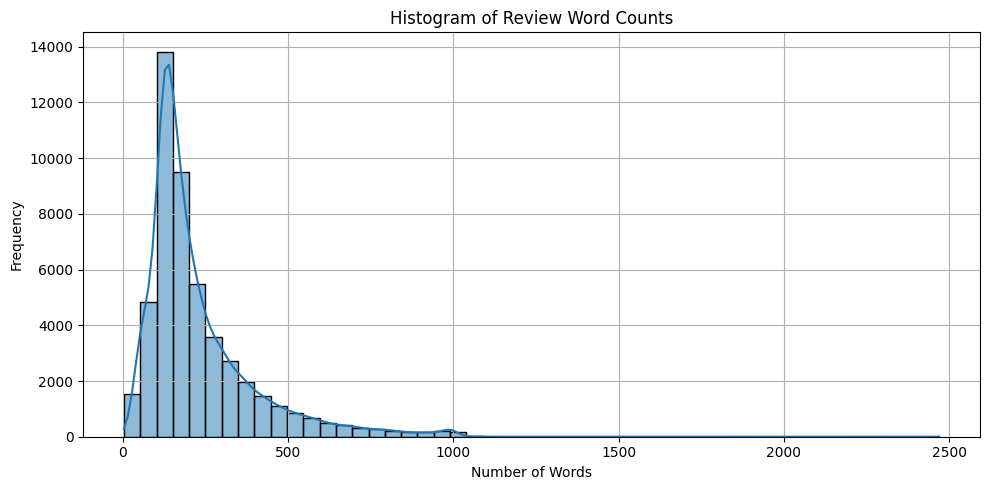

In [55]:
# เพิ่มคอลัมน์ความยาว (จำนวนคำ) ของแต่ละรีวิว
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

# แสดงสถิติเบื้องต้นของความยาวข้อความ (จำนวนคำ)
print("Word Count Statistics:")
print(df['word_count'].describe())


# กราฟการกระจายของจำนวนคำ
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Histogram of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [56]:
# ตัวอย่างข้อความที่ยาวที่สุด
longest_reviews = df.sort_values(by='word_count', ascending=False).head(3)[['word_count', 'review']]
print("\nตัวอย่างข้อความที่ยาวที่สุด:")
display(longest_reviews)



ตัวอย่างข้อความที่ยาวที่สุด:


,word_count,review
31481,2470,Match 1: Tag Team Table Match Bubba Ray and Sp...
40521,2278,There's a sign on The Lost Highway that says:<...
31436,2125,"Back in the mid/late 80s, an OAV anime by titl..."


ตัวอย่างข้อความที่พบจำนวนคำบ่อยที่สุด

In [57]:
# ตัวอย่างข้อความที่พบจำนวนคำบ่อยที่สุด
# นับจำนวนคำที่พบบ่อยที่สุด
most_common_word_count = df['word_count'].value_counts().idxmax()
print(f"\nMost common word count is: {most_common_word_count}")

# แสดงตัวอย่างรีวิวที่มีจำนวนคำเท่ากับค่าที่พบบ่อยที่สุด
most_common_examples = df[df['word_count'] == most_common_word_count][['word_count', 'review','sentiment']].head(3)
print("ตัวอย่างรีวิวที่มีจำนวนคำเท่ากับค่าที่พบบ่อยที่สุด:")
display(most_common_examples)


Most common word count is: 127
ตัวอย่างรีวิวที่มีจำนวนคำเท่ากับค่าที่พบบ่อยที่สุด:


,word_count,review,sentiment
181,127,"This movie is very violent, yet exciting with ...",negative
250,127,"Supposedly a ""social commentary"" on racism and...",negative
299,127,I saw Brother's Shadow at the Tribeca Film Fes...,positive


ตัวอย่างข้อความที่สั้นที่สุด

In [58]:
# ตัวอย่างข้อความที่สั้นที่สุด
# เลือก 10 รีวิวที่มีจำนวนคำน้อยที่สุด
shortest_reviews = df.sort_values(by='word_count').head(10)[['word_count', 'review','sentiment']]
print("\nตัวอย่างข้อความที่สั้นที่สุด:")
display(shortest_reviews)



ตัวอย่างข้อความที่สั้นที่สุด:


,word_count,review,sentiment
28920,4,Primary plot!Primary direction!Poor interpreta...,negative
27521,6,"Read the book, forget the movie!",negative
40817,8,I hope this group of film-makers never re-unites.,negative
13109,8,"More suspenseful, more subtle, much, much more...",negative
31072,9,"What a script, what a story, what a mess!",negative
19874,10,This movie is terrible but it has some good ef...,negative
18400,10,Brilliant and moving performances by Tom Court...,positive
11926,10,I wouldn't rent this one even on dollar rental...,negative
20274,11,You'd better choose Paul Verhoeven's even if y...,negative
48448,12,Adrian Pasdar is excellent is this film. He ma...,positive


## 2.3. สามารถวิเคราะห์เพิ่มเติมในข้อมูลของรีวิวได้ดังนี้

รีวิวสั้น (ประมาณไม่เกิน 20 คำ) :
* มักจะเป็นคำพูดที่ประชดประชันไปเลย
* หรือไม่ก็สรุปสั้นๆที่เจาะจงคำรุนแรงหรือบอกเหตุผลเดียวไปเลย เช่น Don't, not, can't,Like, Love
* หรือจะเปรียบเทียบ เช่น Worst, worse, Better, Best, Equal

รีวิวความยาวที่พบได้บ่อย :
* จะอยู่ในช่วงประมาณ 127 คำ * จะมีการอธิบายเหตุผลที่ชัดเจนว่าทำไมถึงชอบหรือไม่ชอบอยากชัดเจน
* ให้เหตุผลประมาณ 2 - 3 เหตุผล

* นอกจากนี้ยังมีคำที่ให้เหตุผลที่พบได้บ่อยๆคือ But, Eventhough, Even


รีวิวยาว (เกิน 1000 คำ) :
* มักเป็นการอธิบายฉากในหนังไปเลย
* หรือเป็นการกล้าวถึงอ้างอิงหนังเรื่องอื่น
* ซึ่งจะมีการเปรียบเทียบและใช้คำอธิบายตามหนังค่อนข้างเยอะ เป็นฉากๆที่สำคัญ
* ซึ่งบางครั้งข้อมูลเหล่านี้อาจส่งผลให้โมเดลอ่อนไหวกับการทำความเข้าใจข้อความเหล่านี้ได้ เพราะอธิบายละเอียดเกินไป


ข้อสังเกตุเพิ่มเติม:
*  สิ่งที่เห็นได้ชัดคือ ข้อมูลจะมี Tag หรืออักษรแปลกๆขึ้นมาเนื่องจากการเก็บข้อมูลเป็น Text เช่น < br/>
*  Positive และ Negative มีค่าเท่ากันอยู่ที่อย่างละ 25000 รวม 50000
*   มีข้อมูลซ้ำกันบ้างแต่น้อยมาก (ประมาณ 1%)
* คำบางอันอาจจะสื่อความหมายลบ แต่รีวิวเป็น positve


# 3.Preprocess Dataset

ทำการปรับปรุง Dataset เพื่อกำจัดสิ่งที่อาจทำให้โมเดลเกิดความอ่อนไหวในการเทรนได้ ด้วยการตัดข้อมูลที่แปลก หรือ Outlier ต่างๆออกไป

1.  นำข้อมูลที่ซ้ำออก
2.  เก็บไว้แต่ในส่วน 95% ตรงกลาง
3.  นำเครื่องหมายต่างๆที่จะส่งผลได้ เช่น อีโมจิ การแท็ก ลิงค์ต่างๆ หรือ โทเคนเฉพาะในการพิมพ์ข้อความ
4. Tokenized ข้อมูล
 ในส่วนของ DistilBERT ใช้ DistilBertTokenizerFast
 5. แปลง sentiment class เป็นตัวเลข



## 3.1. ลบข้อมูลที่ซ้ำกันออก

เนื่องจากหากมีข้อมูลซ้ำ จะทำให้เกิด

In [59]:
# ตรวจสอบข้อมูลที่ซ้ำกันในคอลัมน์ 'review'
duplicate_reviews = df[df.duplicated(subset='review', keep=False)]

# แสดงจำนวนรีวิวที่ซ้ำ
print(f"Found {len(duplicate_reviews)} duplicated rows.")

# แสดงตัวอย่าง 5 กลุ่มที่ซ้ำกัน
sample_groups = duplicate_reviews.groupby('review').head(1).head(5)['review']
examples = duplicate_reviews[duplicate_reviews['review'].isin(sample_groups)]

print("\nSample duplicated reviews with sentiment:")
display(examples[['review', 'sentiment']])

# ลบข้อมูลซ้ำและสร้าง DataFrame ใหม่ชื่อ filtered_df
filtered_df = df.drop_duplicates(subset='review')

# แสดงผลหลังลบ
print(f"\nRemoved {len(df) - len(filtered_df)} duplicate reviews.")
print(f"Remaining reviews: {len(filtered_df)}")
# del df, duplicate_reviews, examples


Found 824 duplicated rows.

Sample duplicated reviews with sentiment:


,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
84,"We brought this film as a joke for a friend, a...",negative
140,"Before I begin, let me get something off my ch...",negative
219,Ed Wood rides again. The fact that this movie ...,negative
245,I have seen this film at least 100 times and I...,positive
12608,I have seen this film at least 100 times and I...,positive
14117,Ed Wood rides again. The fact that this movie ...,negative
19495,"Before I begin, let me get something off my ch...",negative
25088,"Of all the films I have seen, this one, The Ra...",negative
44392,"We brought this film as a joke for a friend, a...",negative



Removed 418 duplicate reviews.
Remaining reviews: 49582


## 3.2. ตัดอยู่ในช่วง Z

เพื่อให้ข้อมูลนั้นไม่อ่อนไหวหากเจอ Noise หรือ Bias ให้ Attention บางคำเยอะเกินไปใน Review ที่สั้น ลดการ Padding ที่มากเกินไปด้วย

Remaining reviews after Z-score filtering: 46880
Word Count Statistics:
count    46880.000000
mean       201.188396
std        113.769230
min         10.000000
25%        124.000000
50%        167.000000
75%        254.000000
max        574.000000
Name: word_count, dtype: float64


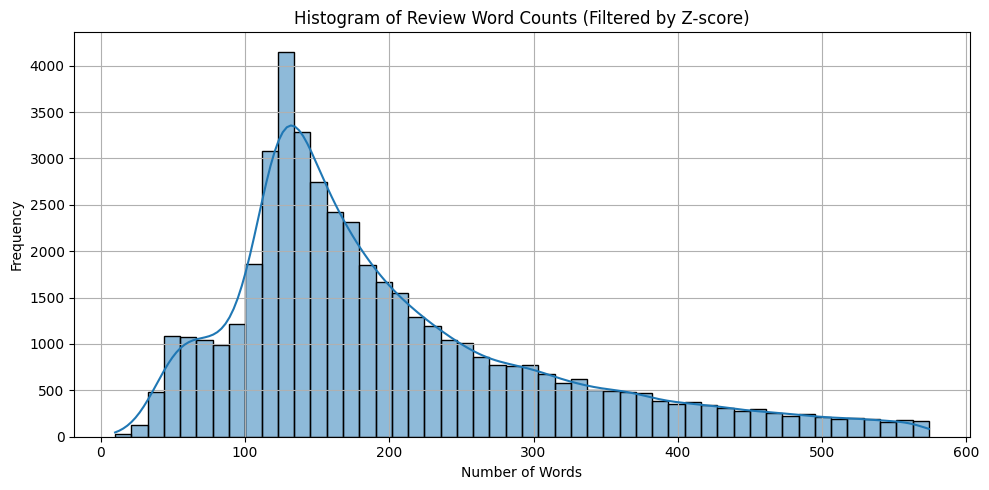

In [60]:
from scipy.stats import zscore

# สร้างสำเนาใหม่จากเดิม (ถ้ายังไม่ได้ copy จริง)
filtered_df = filtered_df.copy()

# เพิ่มคอลัมน์จำนวนคำ
filtered_df.loc[:, 'word_count'] = filtered_df['review'].apply(lambda x: len(str(x).split()))

# คำนวณ Z-score
filtered_df.loc[:, 'z_score'] = zscore(filtered_df['word_count'])

# กรองเฉพาะแถวที่อยู่ในช่วง Z-score -2 ถึง +2
filtered_df = filtered_df[(filtered_df['z_score'] >= -2) & (filtered_df['z_score'] <= 2)]
# กรองเฉพาะแถวที่มี word_count มากกว่า 10 คำ
filtered_df = filtered_df[filtered_df['word_count'] >= 10]

# แสดงจำนวนที่เหลือ
print(f"Remaining reviews after Z-score filtering: {len(filtered_df)}")

# แสดงสถิติเบื้องต้นของความยาวข้อความ (จำนวนคำ)
print("Word Count Statistics:")
print(filtered_df['word_count'].describe())

# กราฟการกระจายของจำนวนคำ (หลัง Z-score filter)
plt.figure(figsize=(10, 5))
sns.histplot(filtered_df['word_count'], bins=50, kde=True)
plt.title("Histogram of Review Word Counts (Filtered by Z-score)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()



จะเห็นว่าเหลือความยาวที่สูงที่สุดเพียง 574 คำ ซึ่งพบได้บ่อยมากพ่อที่จะไม่เป็น Outlier แล้ว

## 3.3. กำจัดโทเคนแปลกๆในข้อความออก
เนื่องจาก BERT tokenizer จะรองรับการทำงานของสัญลักษณ์กรณีต่างๆอยู่แล้ว เช่น
1. กรณีคำที่มี - เช่น "Pre-trained" เพราะเป็น WordPiece จะได้ผลลัพธ์เป็น ['pre', '-', 'trained'] หรือ ['pre', '##trained']
2. กรณีตัวพิมพ์เล็กพิมพ์ใหญ่ ไม่จำเป็น เนื่องจาก ไม่ได้ใช้โมเดล distilbert-base-uncased ที่เทรนผ่านตัว lowercase ทั้งหมด
3. กรณีมี stopword เช่น a, an, the, is, are, was, in, on, at, and, or, of, to, from, by.. ไม่จำเป็นต้องลบ
  * เพราะ BERT ถูก Train ให้เข้าใจบริบทที่เชื่อมกับคำพวกนี้อยู่แล้วด้วย Token พิเศษ
  * หากลบออกไปอาจทำให้บริบทเปลี่ยนและโมเดลทำนายพลาดได้
  * ตัวอย่าง BERT นั้นถูกเทรนมาจาก
    * BooksCorpus ข้อความจากนิยายกว่า 11,000 เล่ม จำนวนคำประมาณ 800 ล้านคำ
    * English Wikipedia  เฉพาะบทความคุณภาพสูงใน Wiki ภาษาอังกฤษ จำนวนคำประมาณ 2,500 ล้านคำ
    *  *(อ้างอิง : BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.
arXiv preprint arXiv:1810.04805
https://arxiv.org/abs/1810.04805*)

4. สามารถตัดคำที่พบเจอได้ทั่วไปในข้อความ เช่น
  - ลิงค์ (http) หรือ break (<br \>)ที่เอาไว้ขึ้นบรรทัดใหม่ เป็นคำทั่วไปที่เจอได้ใน Dataset ที่มี text จากข้อความยาวๆ
  - ตัวอักษรพิเศษที่มักใช้แต่ไม่ค่อยสื่อความหมายให้เข้าใจในบริบทของรีวิว @ # ! & * $ % ต่างๆ

จึงตัดข้อมูลออกมาได้ดังนี้

In [61]:
import re

# ฟังก์ชันสำหรับ clean ข้อความ
def clean_text(text):
    text = re.sub(r'http\S+', '', text)      # ลบลิงก์
    text = re.sub(r'@\w+', '', text)         # ลบ @mention
    text = re.sub(r'#\w+', '', text)         # ลบ hashtag
    text = re.sub(r'[^\w\s]', '', text)      # ลบ punctuation ทุกตัว ยกเว้นตัวอักษร/เลข/เว้นวรรค
    text = re.sub(r'\s+', ' ', text).strip() # ลบช่องว่างซ้ำ
    return text

# สร้างตัวอย่างก่อนทำความสะอาด
cleaned_df = filtered_df[['review','sentiment']].copy()
cleaned_df['review_cleaned'] = cleaned_df['review'].apply(clean_text)

# แสดงผลก่อน-หลัง
print("เปรียบเทียบข้อความก่อนและหลังการ clean:")
display(cleaned_df[['review', 'review_cleaned', 'sentiment']].head(3))

# del filtered_df


เปรียบเทียบข้อความก่อนและหลังการ clean:


,review,review_cleaned,sentiment
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,A wonderful little production br br The filmin...,positive
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,positive


หลังจากกรองข้อมูลอกไปแล้วให้ตรวจสอบและข้อมูลอีกครั้งว่ามีข้อมูลว่างหรือ NaN ไหม เพื่อป้องกันไม่ได้ Token

In [62]:
# แทนที่ review ด้วย review_cleaned
cleaned_df['review'] = cleaned_df['review_cleaned']
cleaned_df.drop(columns=['review_cleaned'], inplace=True)

# ลบแถวที่ review ว่าง หรือมีคำ < 10 คำ
cleaned_df['word_count'] = cleaned_df['review'].apply(lambda x: len(str(x).split()))

# ตรวจสอบว่าแถวไหนว่างหรือสั้น
invalid_rows = cleaned_df[
    (cleaned_df['review'].isnull()) |
    (cleaned_df['review'].str.strip() == '') |
    (cleaned_df['word_count'] < 10)
]

print(f"Number of invalid rows (empty or short): {len(invalid_rows)}")

# แสดงตัวอย่างถ้ามี
if len(invalid_rows) > 0:
    print("ตัวอย่าง review ที่ว่างเปล่าหรือสั้นเกินไป:")
    display(invalid_rows[['review', 'sentiment']].head())

# ลบแถวที่ไม่เหมาะสมออก
cleaned_df = cleaned_df[~cleaned_df.index.isin(invalid_rows.index)]
cleaned_df.drop(columns=['word_count'], inplace=True)

print(f"Remaining valid reviews: {len(cleaned_df)}")


Number of invalid rows (empty or short): 0
Remaining valid reviews: 46880


และแปลง sentiment ให้เป็น 0 กับ 1 เพื่อใช้ในการเป็น label ต่อไป

In [63]:
# แปลง sentiment ให้เป็น label 0/1
cleaned_df['label'] = cleaned_df['sentiment'].map({'negative': 0, 'positive': 1})
print(cleaned_df['label'].value_counts())

# ตัวอย่าง
display(cleaned_df[['review', 'sentiment', 'label']].sample(5, random_state=42))


label
0    23464
1    23416
Name: count, dtype: int64


,review,sentiment,label
35345,Solo is an action movie about a Terminatorlike...,negative,0
29606,When I first heard about this movie I eagerly ...,negative,0
15476,We had to go to an appointment so we turned on...,negative,0
28685,Overall this movie is dreadful and should have...,negative,0
41357,Anyone who has seen the trailer for this film ...,positive,1


## 3.4. กำหนดข้อมูลเพื่อเตรียม Train

ทำการโหลดข้อมูล Train เป็น Batch ซึ่งข้อดีคือ
- Train ข้อมูลแบบ Pararelle - ทำให้ใช้ทรัพยากรประมวลผลได้อย่างมีประสิทธิภาพ
- ลดการใช้หน่วยความจำ (RAM) ในเครื่องประมวลผล ทำให้ session ไม่ Crash จากการกินทรัพยากรเกินไปใน Google collab free
- ลดระยะเวลาในการ Train
- ในตัวอย่างนี้จะแบ่งข้อมูลออกมาเป็น 10000 Train และ 400 test เพื่อลดระยะเวลาในการ Fine-tuning model

ซึ่งจะแบ่งงอกเป็น train  validate test
- เพื่อจะได้ป้องกันการเกิด overfitting
- เปรียบเทียบการทำนายจากขช้อมูลที่เจอแล้วและยังไม่เจอได้ถูกต้อง

In [64]:
# 1. แยก label ออกมา
positive_df = cleaned_df[cleaned_df['label'] == 1].sample(frac=1, random_state=42).reset_index(drop=True)
negative_df = cleaned_df[cleaned_df['label'] == 0].sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Train = 5000 pos + 5000 neg = 10000
train_pos = positive_df.iloc[:5000]
train_neg = negative_df.iloc[:5000]
train_df = pd.concat([train_pos, train_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Validation = 100 pos + 100 neg = 200
val_pos = positive_df.iloc[5000:5100]
val_neg = negative_df.iloc[5000:5100]
val_df = pd.concat([val_pos, val_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Test = 100 pos + 100 neg = 200
test_pos = positive_df.iloc[5100:5200]
test_neg = negative_df.iloc[5100:5200]
test_df = pd.concat([test_pos, test_neg]).sample(frac=1, random_state=42).reset_index(drop=True)


## 3.5. การ Tokenize ข้อมูล

โดยจะใช้เป็น Hugging face API คือ from_pretrained(distilbert-base-uncased)

tokenize คือกระบวนการแปลงข้อความ (เช่น ประโยครีวิว) ให้กลายเป็นลำดับตัวเลขที่โมเดล DistilBERT เข้าใจได้ โดยจะแยกคำหรือ subword ออกมาแล้วแมปเป็น token ID

ทำไปทำไม:
เพราะโมเดลไม่เข้าใจข้อความดิบ ต้องแปลงเป็นตัวเลขก่อนฝึกหรือทำนาย

ตัวอย่าง:
ข้อความ: "I love this movie"
→ Tokenize → ["I", "love", "this", "movie"]
→ Token ID → [100, 3674, 1142, 1297] (ค่าจำลอง)


ซึ่งจะมีส่วนหลักคือ

1. input id = id ของ Token ที่ต่างกันที่ Mapping ไว้ของโมเดล

2. attention mask = ระบุว่า Token ไหนใช้สำหรับเรียนรู้จริงๆ

3. Special token mask = เอาไว้บอก Token พิเศษ คือ
  - [CLS] = ใช้ในการเริ่มประโยคเพื่อ Classification มี ID = 101
  - [SEP] = ใช้คั่นประโยค Seperate ID = 102
  - [PAD] = ใช้สำหรับ padding เพื่อให้ความยาวเต็มที่ ID = 0


In [65]:
from transformers import DistilBertTokenizerFast
from tqdm import tqdm
import torch

# โหลด tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

### การตั้งค่า Tokenizer



1. เนื่องจากตัวอย่างส่วนใหญ่ 90% ยาวอยู่ที่ช่วงข้อความ 50-200 คำ
 * จึงตั้งค่าความยาว Token สูงสุดของแต่ละชุดตัวอย่าง
 * อยู่ที่ max_length = 128

2. ซึ่งบางตัวอย่างจะมีความยาวเกิน 128 token
 * จะต้องตั้งค่าให้ทำการตัด Token ที่เกินจากชุดตัวอย่างออก
 * แล้วแยกข้อมูล Token ให้เป็นชุดใหม่เพื่อให้นำไป Train ต่อได้
 * ด้วยการเรียกตั้งค่า trunicate = true

3. และต้องทำการ Padding ให้ทุกข้อมูลมีความยาวเท่ากัน ตาม max_length ของแต่ละ batch
 * เพราะ BERT จะเรียนรู้ข้อมูลแบบความยาวเท่ากัน หากไม่มีข้อมูลในความยาวที่น้อยกว่าก็จะใช้เป็น attention mask ในการมาช่วยเหลือแทน
 * แต่เนื่องจากเราแบ่งทำงานเป็น batch จึงทำงานแบบ dynamic padding (padding เรียนตามความยาวสุดของแต่ละ Batch)

4. นอกจากนี้ ยังมีบางคำที่อาจไม่อยู่ใน vocab ของ tokenizer ก็ไม่จำเป็นต้องตัดออก เพราะการทำงานของ distilBertTokenizer จะเป็นแบบ wordpiece
* wordpeice คือ
* ซึ่งหากเจอคำที่ไม่รุ้จักจะแตกออกเป็น subword เช่น ['movvvie'] จะกลายเป็น ['mo', '##vv', '##vie'] ทำให้สามารถเรียนรู้และทำงานต่อไปได้ ไม่ต้องมีโทเคน [UNK]

5. และในส่วนของคำบางคำที่ไม่ใช่ lowercase ทั้งหมดนั้น
* เช่น ['Movie', 'MOVIE', 'moVie']
* tokenizer(distilbert-base-uncased) จะแปลงเป็น ['movie'] แบบ lowercase ทั้งหมดให้อัตโนมัติ
* จึงไม่จำเป็นต้องจัดการเพราะจะนับทุกตัวเป็น ID เดียวกันทั้งหมด

In [66]:
# Tokenize ข้อมูล
def tokenize_data(df):
    return tokenizer(
        df['review'].tolist(),
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

train_encodings = tokenize_data(train_df)
val_encodings = tokenize_data(val_df)
test_encodings = tokenize_data(test_df)

train_labels = train_df['label'].tolist()
val_labels = val_df['label'].tolist()
test_labels = test_df['label'].tolist()


# ตัวอย่างเปรียบเทียบ (3 ตัวอย่างจาก cleaned_df)
sample_short = train_df.iloc[:3]

# แสดงข้อความต้นฉบับ
print("ตัวอย่างข้อความต้นฉบับ:")
for i, text in enumerate(sample_short['review']):
    print(f"\nExample {i+1}:\n{text}\n")

# Tokenize ตัวอย่างเพื่อแสดงผล
tokenized_sample = tokenizer(
    sample_short['review'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

# แสดงผล tokenization
print("\nเปรียบเทียบผลลัพธ์หลัง Tokenization:\n")
for i in range(3):
    tokens = tokenizer.convert_ids_to_tokens(tokenized_sample['input_ids'][i])
    input_ids = tokenized_sample['input_ids'][i].tolist()
    attention_mask = tokenized_sample['attention_mask'][i].tolist()

    print(f"Example {i+1}:")
    print(f"Tokens        : {tokens[:20]} ...")
    print(f"Input IDs     : {input_ids[:20]} ...")
    print(f"Attention Mask: {attention_mask[:20]} ...")
    print("-" * 100)

ตัวอย่างข้อความต้นฉบับ:

Example 1:
One of the worst movies Ive ever seen with Robert De Niro The Fan is a pointless cliché of an exercise in slasher flicks It tries to spin or twist the genre with preposterous plot lines of a a crazed fan turned psychotic the movie meanders into nothing spoiler Were to believe that a knifewielding idiot has access to and murders a baseball player in a lavish hotel with no witness security or cameras The movie is nonsense trying to tug at our heartstrings through the hoopla of baseball ending up mockingly unsophisticated and gimmicky Not sure what all the actors were thinking when they got onboard this razzie This is as big a dud as they come Stay far away if you prefer thought in your movies


Example 2:
Best club scenes that i have seen in a long time atmosphere mesmerising matthew Rhyss performance is impeccable and faultless i would recommend this film to any age group watch out for wonderwoman


Example 3:
Taylor Hackford wanted to make this movie

จากตัวอย่างก็จะเห็นได้ว่าการ Tokenizied นั้น จัดการกับทุกรณีที่ได้อธิบายไว้ในตอนต้นแล้ว ดังนี้
 - เพิ่ม Token เริ่มและจบ
 - ลบ Tag หรืออักษรประหลาดออก
 - คำที่เป็น OoV จะถูกแยกออกเป็น WordPiece

# 4.Fine-Tuning Model

## 4.1. สร้างและกำหนดค่าโมเดล

เลือกใช้ DistilBERT model เพื่อ Fine-tuning ในหัวข้อ Sentimental analysis โดยมี dataset เป็นการรีวิวหนังจาก IMDB (อธิบายเพิ่มเติมในรายงาน)


## 4.2. โครงสร้างของโมเดลมีดังนี้

1. Input

- input_ids

 เป็นลำดับของ token ID ที่ได้จากการแปลงคำหรือ subwords ด้วย Tokenizer

 ตัวอย่าง: "I love NLP" → ["[CLS]", "i", "love", "nlp", "[SEP]"] → [101, 1045, 2293, 3793, 102]

 [CLS] คือ token เริ่มต้นที่ใช้เป็นตัวแทนของทั้งประโยค (output ของมันจะนำไปใช้ในการ classification)

 [SEP] คือ token สำหรับแยกประโยค ในกรณีมีมากกว่า 1 ประโยค แต่กรณีในข้อมูลนี้ไม่ได้ถูกใช้งานเนื่องจากนับว่า 1 รีวิวคือ 1 ข้อความรวมกัน


- attention_mask

 เป็นลำดับของค่า 1 และ 0 เพื่อบอกโมเดลว่าตำแหน่งใดควรถูกใช้ในการประมวลผล

 ค่า 1 หมายถึง token ที่สำคัญ, ค่า 0 สำหรับ padding (ไม่ให้โมเดลสนใจ)


2. Embedding

 ก่อนส่งข้อมูลเข้า Transformer encoder, โมเดลจะนำ input_ids มาสร้างเวกเตอร์ผ่าน embedding layer โดยมี 3 ส่วนรวมกัน:

- Token Embedding

 แทนความหมายของแต่ละ token ด้วยเวกเตอร์

- Position Embedding

 เพิ่มข้อมูลตำแหน่งของแต่ละ token เพื่อให้โมเดลเข้าใจลำดับ (เพราะ Transformer ไม่มีโครงสร้างลำดับเหมือน RNN)

- Segment Embedding

 ระบุว่าแต่ละ token มาจากประโยคใด (ในกรณีมีหลายประโยค เช่นใน NSP) ซึ่งไม่มีการใช้งาน

 ผลลัพธ์ของ embedding จะรวมกันและส่งเข้า Transformer layer

3. Output
- เมื่อข้อมูลผ่าน embedding และ Transformer encoder หลายชั้นแล้ว โมเดลจะส่งผลลัพธ์ออกมาในรูปแบบของ tensor ที่มีขนาด [batch_size, sequence_length, hidden_size] ซึ่งใน classification task จะใช้ output ที่สอดคล้องกับ token [CLS] เพียงตัวเดียว ซึ่งมีขนาด [batch_size, hidden_size]

output ดังกล่าวจะถูกส่งต่อเข้า linear layer เพื่อให้โมเดลทำนาย label ต่อไป

โดยการทำงานดังนี้

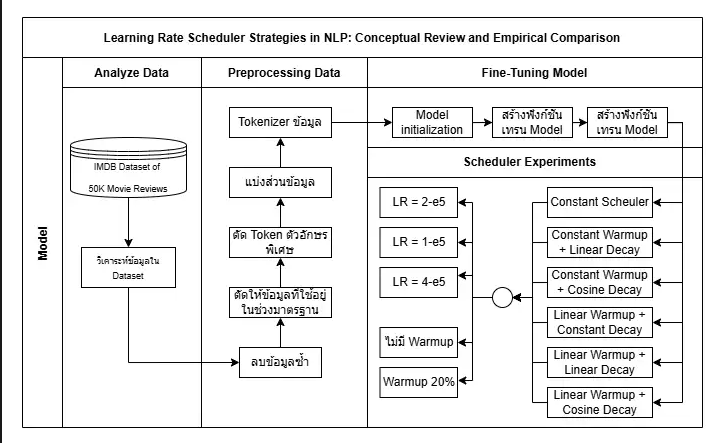


## 4.3. Model initialization

นำ dataset เข้า dataloader โดยมีการเตรียมดังนี้
1. IMDbDataset
เป็นคลาสที่สืบทอดจาก torch.utils.data.Dataset ใช้เก็บ input_ids, attention_mask และ labels

 - __getitem__ คืนข้อมูล 1 ตัวอย่างตาม index

 - __len__ บอกจำนวนทั้งหมดใน dataset

2. สร้าง Dataset
จาก encodings ที่ได้จาก tokenizer + labels

3. ใช้ DataLoader เพื่อแบ่ง dataset ออกเป็น batch สำหรับใช้ใน training

 - batch_size=64 หมายถึงส่งข้อมูล 64 ตัวอย่างต่อ 1 step

 - shuffle=True เฉพาะ train เพื่อให้โมเดลไม่จำลำดับ

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

# IMDbDataset class
class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# สร้าง Dataset
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

# สร้าง DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)


### ค่าตัวแปรที่ติดตามผล

1. น้ำหนักของโมเดลที่ดีที่สุด (best_model_state_dict)

- บันทึกเป็นไฟล์ .pt เช่น model_linear.pt

- ใช้โหลดกลับมา inference หรือ deploy ได้ในภายหลัง

- เป็นโมเดลที่ให้ค่า validation accuracy สูงที่สุดระหว่างการฝึก

สรุปผลการฝึกในแต่ละ epoch (training_summary_*.csv)

- เก็บข้อมูล train/val loss, accuracy, เวลาที่ใช้ต่อ epoch และค่า learning rate

- ใช้ดูพฤติกรรมการลู่เข้าของโมเดล และวิเคราะห์ว่า scheduler ไหนให้ผลลัพธ์ดีที่สุด

log รายละเอียดของ learning rate (lr_logs_*.csv)

- เก็บค่าความเปลี่ยนแปลงของ learning rate ในแต่ละ training step

- ใช้ตรวจสอบว่า scheduler ทำงานตามที่ออกแบบไว้หรือไม่ (เช่น warm-up แล้วค่อย decay)

- เหมาะสำหรับการวาดกราฟ LR ต่อ step เพื่อดูพฤติกรรมแบบละเอียด

In [ ]:
def save_experiment_logs(logs, scheduler_name, base_dir):
    save_path = os.path.join(base_dir, scheduler_name)
    os.makedirs(save_path, exist_ok=True)

    # Save best model
    torch.save(logs['best_model_state_dict'], os.path.join(save_path, f"model_{scheduler_name}.pt"))

    # Save training summary
    df_summary = pd.DataFrame({
        'epoch': list(range(1, 1 + len(logs['train_loss']))),
        'train_loss': logs['train_loss'],
        'val_loss': logs['val_loss'],
        'train_acc': logs['train_acc'],
        'val_acc': logs['val_acc'],
        'epoch_time': logs['epoch_durations'],
        'lr': logs['lr_per_epoch']
    })
    df_summary.to_csv(os.path.join(save_path, f"training_summary_{scheduler_name}.csv"), index=False)

    # Save LR logs
    df_lr_logs = pd.DataFrame(logs['lr_logs'])
    df_lr_logs.to_csv(os.path.join(save_path, f"lr_logs_{scheduler_name}.csv"), index=False)


## 4.4. Training configuration

ทำการเตรียมการเทรนและการตั้งค่าซึ่งเป็นค่า Default ที่นิยมใช้ในการ Fine-tunig DistilBERT (อ้างอิงจาก Trainer module ใน Hugging face API) ดังนี้


- model: โมเดลเช่น DistilBERT ที่จะถูกฝึก

- train_loader, val_loader: DataLoader สำหรับ training และ validation set

- optimizer: Optimizer เช่น AdamW

- loss_fn: ฟังก์ชัน loss เช่น CrossEntropyLoss

- device: เช่น "cuda" หรือ "cpu"

- num_epochs: จำนวนรอบการฝึก

- scheduler_name: ชื่อ scheduler สำหรับอ้างอิงหรือ log

- scheduler: ตัว scheduler ที่จะใช้ปรับ learning rate

### กำหนดรูปแบบ Scheduler ที่ต้องการทดลอง
มีรูปแบบ Scheduler ที่นิยมใช้กับ DistilBERT คือ Linear และ Cosine (อ้างอิงจาก Hugging face trainer API,Timm (PyTorch Image Models),PyTorch Lightning,Keras / TensorFlow)

โดยในส่วน Scheduler ที่สนใจใช้ศึกษามี 2 ส่วนหลักดังนี้
1. Warm up : เป็นการกำหนดให้ Learning rate เริ่มต้นนั้นต่ำกว่าค่าสูงสุดที่ต้องการ โดยทั่วไปมักทำอยู่ที่ 10-15% ซึ่งจะช่วยในการป้องกันโมเดลกระโดดสูงมากเกินไปและค่าเออเร่อเพิ่มในช่วงต้นของการฝึก
2. Decay : เป็นการกำหนดให้ Learning rate ค่อยๆลดลงในการเรียนรู้รอบถัดๆไป เพื่อให้ค่าสามารถลู่เข้าไปเรียนรู้ข้อมูลในการนำมาอัพเดต Weight ได้ดีที่สุด ยิ่งค่าน้อยลงจะยิ่งอัพเดตได้ละเอียดมากขึ้น แต่ก็อาจเกิด Overfittign ได้หากละเอียดมากเกินไป
3. Optimizer: AdamW
ใช้สำหรับอัปเดตน้ำหนักโมเดล โดยแยก weight decay ออกจากการคำนวณ gradient ทำให้เหมาะกับการ fine-tune โมเดล Transformer และเป็นค่า default ที่ HuggingFace แนะนำ
ตั้งค่า learning rate ไว้ที่ 2e-5 ซึ่งเป็นค่าที่เหมาะสมกับการ fine-tune pre-trained model โดยไม่ทำให้เกิดการกระโดดของ gradient



- Constant learning rate
- Constant warmup + linear decay learning rate
- Constant warmup + cosine decay learning rate
- Linear warmup + constant learning rate
- Linear warmup + linear decay learning rate
- Linear warmup + cosine decay learning rate

In [ ]:
# Imports and Setup
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm
import numpy as np
import time
from collections import deque
import pandas as pd
import os
import matplotlib.pyplot as plt
from torch.cuda.amp import GradScaler
from torch.amp import autocast
import math

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
os.makedirs(base_dir, exist_ok=True)

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
scaler = GradScaler() if torch.cuda.is_available() else None
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-21-39c226d01dce>:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if torch.cuda.is_available() else None


### รูปแบบการทำงานของการเทรน Fine-tuning โมเดลเข้ากับ Dataset มีดังนี้

1. แบ่งข้อมูลเป็น Batch ก่อนเทรนด้วย dataloader
 - Dataset จะถูกแบ่งออกเป็นชุดย่อยที่มีขนาดเท่ากัน คือ batch

 - 10,000 ตัวอย่าง และ batch size = 64 → ได้ 157 batch (step) ต่อ epoch

 - การใช้ batch ช่วยให้ฝึกได้เร็วขึ้นและเสถียรกว่าการอัปเดตทีละตัวอย่าง แต่ถ้าใหญ่เกินไปอาจทำให้ RAM ไม่พอ ( Google colab หลุด)

2. เทรนแต่ละ Epoch
Epoch = การที่โมเดลเห็นข้อมูลครบทั้ง dataset 1 รอบ

 - 1 epoch ประกอบด้วยหลาย step (จำนวน batch ทั้งหมดจาก Dataset/Batch size)

 - จะวนลูปผ่าน batch ทีละชุดในแต่ละ epoch

3. ฝึกในแต่ละ Step (1 batch ต่อครั้ง)
ในแต่ละ step จะทำตามลำดับนี้:

 - ดึง batch จาก DataLoader

 - ส่ง input (input_ids, mask, label) เข้าโมเดล

 - คำนวณ loss (ความคลาดเคลื่อน)

 - คำนวณ gradient (backpropagation)

 - อัปเดต weight ของโมเดล ด้วย optimizer เช่น AdamW

 - ถ้ามี scheduler → ปรับ learning rate ในรอบนี้ตามที่ได้ตั้งค่าไว้

 - หลังจากนี้ step จะวนไปยัง batch ถัดไปใน epoch

4. ครบ 1 Epoch → ประเมิน Validation / บันทึก
 - เมื่อครบทุก batch ใน 1 epoch:

    - หยุดฝึกชั่วคราวและประเมินบน validation set

    - เก็บค่า loss, accuracy, learning rate, เวลา ฯลฯ

    - หาก validation ดีขึ้น → เก็บโมเดลเป็น best model

 - จากนั้นเริ่ม epoch ถัดไป จนจบครบ num_epochs ที่กำหนดไว้

### ฟังก์ชันในการเทรนโมเดล มีการทำงานดังนี้

1. เตรียมค่าเริ่มต้น
 - กำหนด list สำหรับเก็บ loss, accuracy, เวลา และ learning rate แต่ละ epoch

 - ย้ายโมเดลไปยัง device

 - ตั้งค่าตัวแปรสำหรับเก็บโมเดลที่ดีที่สุด (best_model_state_dict)

2. เริ่มลูปฝึกในแต่ละ epoch
 - ตั้งโหมด model เป็น train()

 - บันทึกเวลาเริ่มต้น

 - ใช้ deque เพื่อเก็บค่า loss/accuracy เฉลี่ยแบบ rolling (ล่าสุด 100 ค่า)

3. ลูปผ่านแต่ละ batch ใน train_loader
 - ส่ง input_ids, attention_mask, labels ไปยัง device

 - ล้าง gradient (optimizer.zero_grad())

 - ถ้าใช้ mixed precision (ใช้ GPU มี scaler):

    - ใช้ autocast() เพื่อเร่งความเร็ว

    - คำนวณ loss แล้ว backward + optimizer step แบบ scaling

 - ถ้าไม่ใช้ scaler (ใช้ CPU) เป็นหลัก:

    - คำนวณ logits และ loss ตามปกติ แล้ว backward + step

 - ถ้ามี scheduler: .step() เพื่ออัปเดต LR

 - คำนวณ accuracy จาก logits → preds

 - บันทึก loss และ accuracy เข้า train_loss_stat, train_acc_stat

 - ทุก 10 step: log ค่า learning rate

4. หลังจบ epoch
 - บันทึกเวลาใช้ต่อ epoch

 - คำนวณค่าเฉลี่ยของ loss และ accuracy ใน epoch นั้น

 - บันทึก learning rate

5. เริ่ม Validation
สลับ model ไปเป็น eval()

 - ไม่เก็บ gradient (torch.no_grad())

 - วน loop val_loader → เก็บ preds และ labels

 - คำนวณ val_acc และ val_loss จากผลลัพธ์สุดท้าย

6. ตรวจสอบและเก็บโมเดลที่ดีที่สุด
 - ถ้า val_acc ดีกว่าที่เคยมี → เก็บ state_dict ของโมเดลนี้

7. พิมพ์ผลลัพธ์
 - แสดง accuracy ของ train/val พร้อมเวลาใช้ใน epoch นี้


In [ ]:
def train_model_lr(model, train_loader, val_loader, optimizer, loss_fn, device, num_epochs, scheduler_name, scheduler=None):
    train_loss_per_epoch, val_loss_per_epoch = [], []
    train_acc_per_epoch, val_acc_per_epoch = [], []
    epoch_durations, lr_per_epoch = [], []
    lr_logs = []

    model.to(device)
    best_val_acc = 0
    best_model_state_dict = None
    global_step = 0

    for epoch in range(num_epochs):
        model.train()
        start_time = time.time()
        train_loss_stat = deque(maxlen=100)
        train_acc_stat = deque(maxlen=100)

        for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            if scaler:
                with autocast(device_type=device_type):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = loss_fn(outputs.logits, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels)
                loss.backward()
                optimizer.step()


            if scheduler:
                scheduler.step()

            preds = torch.argmax(outputs.logits, dim=1)
            acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

            train_loss_stat.append(loss.item())
            train_acc_stat.append(acc)

            if global_step % 10 == 0:
                lr_logs.append({'step': global_step, 'epoch': epoch, 'lr': optimizer.param_groups[0]['lr']})

            global_step += 1

        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_durations.append(epoch_duration)

        train_loss_per_epoch.append(np.mean(train_loss_stat))
        train_acc_per_epoch.append(np.mean(train_acc_stat))
        lr_per_epoch.append(optimizer.param_groups[0]['lr'])

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs.logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_loss = loss_fn(outputs.logits, labels).item()

        val_loss_per_epoch.append(val_loss)
        val_acc_per_epoch.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state_dict = model.state_dict()

        print(f"Epoch {epoch+1}: Train Acc={train_acc_per_epoch[-1]:.4f}, Val Acc={val_acc:.4f}, Time={epoch_duration:.2f}s")

    return {
        'train_loss': train_loss_per_epoch,
        'val_loss': val_loss_per_epoch,
        'train_acc': train_acc_per_epoch,
        'val_acc': val_acc_per_epoch,
        'epoch_durations': epoch_durations,
        'lr_per_epoch': lr_per_epoch,
        'lr_logs': lr_logs,
        'best_model_state_dict': best_model_state_dict
    }


### 1 Fine-tuning ด้วยการตั้งค่าแบบ Default ( 10% warm up + Learning rate = 2E-5)

โดย Scheduler แต่ละแบบจะถูกสร้างและเรียกใช้ดังที่อธิบายตาม Scheduler ทั้ง 6 แบบในข้างต้น ซึ่งจะมีพารามิเตอร์หลักในการตั้งค่าให้เหมือนกันดังนี้

- Model DistilBERT เพื่อดึงโมเดล Pre-trained มาใช้จาก Hugging face API

- Optimizer: AdamW
ใช้สำหรับอัปเดตน้ำหนักโมเดล โดยแยก weight decay ออกจากการคำนวณ gradient ทำให้เหมาะกับการ fine-tune โมเดล Transformer และเป็นค่า default ที่ HuggingFace แนะนำ


- Loss Function: CrossEntropyLoss
ใช้กับงาน classification แบบสองคลาส ซึ่งเป็น Default ของงานนี้ โดยจะแปลง Softmax ของค่าที่ได้ เปรียบเทียบกับ log loss เพื่อการทำนายแบบคลาสที่แบ่งไว้


- จำนวน epoch: 20
เพื่อให้โมเดลได้เรียนรู้เพียงพอโดยไม่ยืดเยื้อจนเกิด overfitting และมีจำนวนมากพอที่ทำให้เห็นพฤติกรรมต่างๆของโมเดลได้

- การคำนวณ total_steps และ warmup_steps
คำนวณจากจำนวน batch ต่อ epoch (steps_per_epoch) คูณด้วยจำนวน epoch เพื่อใช้ในการควบคุม schedule ของ learning rate

- การบันทึกผลลัพธ์ (logs) และน้ำหนักโมเดลที่ดีที่สุด
เพื่อใช้วิเคราะห์ performance ภายหลัง และนำโมเดลที่แม่นยำที่สุดไปใช้ทำนายจริง

- กำหนด Device ให้ทำงานบน GPU ซึ่งจะช่วยให้ประมวลผลได้เร็วกว่า CPU มากๆ ในที่นี้จะใช้เป็น GPU Tesla 4 จาก Google colab แบบฟรี

#### 1.1 Constant Learning rate (No scheduler)

In [ ]:
# Scheduler แบบที่ 1: constant learning rate
from torch.optim import AdamW

name = "constant"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss()

#  ไม่มี scheduler(constant)
logs = train_model_lr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    num_epochs=20,
    scheduler_name=name,
    scheduler=None
)

# บันทึก logs และ best model
save_experiment_logs(logs, name, base_dir)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.8492, Val Acc=0.8850, Time=26.71s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: Train Acc=0.8975, Val Acc=0.9050, Time=27.28s


...

Epoch 18: Train Acc=0.9964, Val Acc=0.8800, Time=26.94s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9952, Val Acc=0.8900, Time=27.32s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9959, Val Acc=0.9100, Time=26.47s


#### 1.2 Constant warm up + Linear decay scheduler ( No warm up)

In [ ]:
# Custom scheduler: constant + linear decay
def constant_then_linear_scheduler(total_steps, warmup_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return 1.0
        else:
            remaining_steps = total_steps - current_step
            decay_steps = total_steps - warmup_steps
            return max(0.0, remaining_steps / decay_steps)
    return lr_lambda


In [ ]:
# Scheduler แบบที่ 2: constant_then_linear
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

name = "constant_then_linear"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss()

# Estimate total steps
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * 20
warmup_steps = int(0.1 * total_steps)

# Custom LR scheduler
lr_scheduler = LambdaLR(optimizer, lr_lambda=constant_then_linear_scheduler(total_steps, warmup_steps))

# Run training
logs = train_model_lr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    num_epochs=20,
    scheduler_name=name,
    scheduler=lr_scheduler
)


# บันทึก logs และ best model
save_experiment_logs(logs, name, base_dir)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.8481, Val Acc=0.9000, Time=26.54s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: Train Acc=0.8889, Val Acc=0.8850, Time=27.44s


...

Epoch 18: Train Acc=0.9989, Val Acc=0.8950, Time=26.27s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9983, Val Acc=0.8850, Time=26.29s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9986, Val Acc=0.8950, Time=26.26s


#### 1.3 Constant warmup + cosine decay scheduler (No warm up)

In [ ]:
# Scheduler: constant + cosine decay
def constant_warmup_cosine_decay_scheduler(total_steps, warmup_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return 1.0  # constant warm-up
        progress = (current_step - warmup_steps) / (total_steps - warmup_steps)
        return max(0.0, 0.5 * (1 + math.cos(math.pi * progress)))
    return lr_lambda


In [ ]:
# Scheduler แบบที่ 3: constant_then_cosine
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
# CONFIG
scheduler_name = "constant_then_cosine"
learning_rate = 2e-5
num_epochs = 20
base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warmup_ratio = 0.1


# Model + Optimizer
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.CrossEntropyLoss()

# Scheduler setup
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * num_epochs
warmup_steps = int(warmup_ratio * total_steps)
scheduler = LambdaLR(optimizer, lr_lambda=constant_warmup_cosine_decay_scheduler(total_steps, warmup_steps))

# Train
logs = train_model_lr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    num_epochs=num_epochs,
    scheduler_name=scheduler_name,
    scheduler=scheduler
)

# Save
save_experiment_logs(logs, scheduler_name, base_dir)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.8552, Val Acc=0.8900, Time=26.57s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: Train Acc=0.8959, Val Acc=0.9000, Time=26.74s


...

Epoch 18: Train Acc=0.9986, Val Acc=0.8850, Time=26.31s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9992, Val Acc=0.8850, Time=26.28s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9995, Val Acc=0.8850, Time=26.25s


#### 1.4 Linear warm up + constant learing rate scheduler (No decay)

In [ ]:
# Scheduler: Linear warm-up + Constant
def linear_then_constant_scheduler(total_steps, warmup_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return current_step / warmup_steps
        else:
            return 1.0
    return lr_lambda


In [ ]:
# Scheduler แบบที่ 4: linear_then_constant
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

name = "linear_then_constant"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 2e-5
num_epochs = 20
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
optimizer = AdamW(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.CrossEntropyLoss()

#  คำนวณจำนวน step
steps_per_epoch = len(train_loader)  # batch = 64 → 157 steps/epoch
total_steps = steps_per_epoch * 20   # 20 epoch
warmup_steps = int(0.1 * total_steps)  # 10%

#  สร้าง scheduler
scheduler = LambdaLR(optimizer, lr_lambda=linear_then_constant_scheduler(total_steps, warmup_steps))

#  เทรน 20 epoch
logs = train_model_lr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    num_epochs=20,
    scheduler_name=name,
    scheduler=scheduler
)

# บันทึก logs และ best model ลง Google Drive
save_experiment_logs(logs, name, base_dir)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.7698, Val Acc=0.8450, Time=26.93s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: Train Acc=0.8672, Val Acc=0.8700, Time=26.73s


...

Epoch 18: Train Acc=0.9961, Val Acc=0.8800, Time=26.57s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9972, Val Acc=0.8750, Time=26.62s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9919, Val Acc=0.8850, Time=26.47s


#### 1.5 Linear warm up + linear decay scheduler

In [ ]:
# Scheduler: Linear warm-up + Linear decay
def linear_scheduler(total_steps, warmup_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return current_step / warmup_steps
        else:
            remaining_steps = total_steps - current_step
            decay_steps = total_steps - warmup_steps
            return max(0.0, remaining_steps / decay_steps)
    return lr_lambda


In [ ]:
# Scheduler แบบที่ 5: linear (linear warm-up + linear decay)
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

name = "linear"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 2e-5
num_epochs = 20
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
optimizer = AdamW(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.CrossEntropyLoss()

#  Step config
steps_per_epoch = len(train_loader)         # ~157 steps (batch size 64)
total_steps = steps_per_epoch * 20          # 20 epochs
warmup_steps = int(0.1 * total_steps)       # 10%

#  สร้าง scheduler
scheduler = LambdaLR(optimizer, lr_lambda=linear_scheduler(total_steps, warmup_steps))

#  เทรน
logs = train_model_lr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    num_epochs=20,
    scheduler_name=name,
    scheduler=scheduler
)

#  บันทึก best model + log
save_experiment_logs(logs, name, base_dir)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.7695, Val Acc=0.8500, Time=26.84s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: Train Acc=0.8569, Val Acc=0.8900, Time=26.87s


...

Epoch 18: Train Acc=0.9980, Val Acc=0.8950, Time=26.55s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9989, Val Acc=0.9000, Time=26.52s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9988, Val Acc=0.9000, Time=26.72s


#### 1.6 Linear warm up + Cosine decay scheduler

In [ ]:
import math

#  Scheduler: Linear warm-up + Cosine decay
def cosine_scheduler(total_steps, warmup_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return current_step / warmup_steps
        else:
            progress = (current_step - warmup_steps) / (total_steps - warmup_steps)
            return max(0.0, 0.5 * (1 + math.cos(math.pi * progress)))
    return lr_lambda


In [ ]:
#  Scheduler แบบที่ 6: cosine (linear warm-up + cosine decay)
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

name = "cosine"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 2e-5
num_epochs = 20
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
optimizer = AdamW(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.CrossEntropyLoss()

#  Step config
steps_per_epoch = len(train_loader)         # ~157 steps (batch size 64)
total_steps = steps_per_epoch * 20          # 20 epochs
warmup_steps = int(0.1 * total_steps)       # 10%

#  สร้าง scheduler
scheduler = LambdaLR(optimizer, lr_lambda=cosine_scheduler(total_steps, warmup_steps))

#  เทรน
logs = train_model_lr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    num_epochs=20,
    scheduler_name=name,
    scheduler=scheduler
)

# บันทึก best model + logs
save_experiment_logs(logs, name, base_dir)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.7916, Val Acc=0.8600, Time=27.27s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: Train Acc=0.8658, Val Acc=0.8750, Time=26.64s


...

Epoch 18: Train Acc=0.9986, Val Acc=0.8950, Time=26.53s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9984, Val Acc=0.9000, Time=26.51s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9986, Val Acc=0.9000, Time=26.54s


### 2 Fine tuning การทดลองที่ 1 : ปรับจำนวนปรับค่า Learning rate

#### 2.1 Learning rate = 1e-5

ปรับค่า Learning rate ให้เริ่มต้นที่ 1e-5 และเป็นเป้าหมายให้จุด warm up ไต่ไปถึง
ซึ่งหลักการทำงานการเทรนเหมือนกับที่อธิบายไว้ข้างบน แต่ฟังก์ชันเทรนจะเป็นลูปอัตโนมัติไล่ไปตามแต่ละ Scheduler ที่กำหนดไว้ 6 แบบ

In [ ]:
import math
import os
import pandas as pd
import matplotlib.pyplot as plt
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# ตั้งค่าหลัก
learning_rate = 1e-5
num_epochs = 20
base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Scheduler functions
def constant_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0

def constant_then_linear_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0 if step < warmup_steps else max(0.0, (total_steps - step) / (total_steps - warmup_steps))

def constant_then_cosine_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0 if step < warmup_steps else max(0.0, 0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / (total_steps - warmup_steps))))

def linear_then_constant_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else 1.0

def linear_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else max(0.0, (total_steps - step) / (total_steps - warmup_steps))

def cosine_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else max(0.0, 0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / (total_steps - warmup_steps))))

# รายชื่อ scheduler และ function
scheduler_configs = {
    "constant": constant_scheduler,
    "constant_then_linear": constant_then_linear_scheduler,
    "constant_then_cosine": constant_then_cosine_scheduler,
    "linear_then_constant": linear_then_constant_scheduler,
    "linear": linear_scheduler,
    "cosine": cosine_scheduler
}

# Loop ผ่าน scheduler ทั้งหมด
for sched_name, sched_fn in scheduler_configs.items():
    full_name = f"{sched_name}_lr1e5"
    print(f"\n🚀 Training: {full_name}")

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.CrossEntropyLoss()

    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = int(0.1 * total_steps)

    scheduler = LambdaLR(optimizer, lr_lambda=sched_fn(total_steps, warmup_steps))

    # เทรน
    logs = train_model_lr(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        num_epochs=num_epochs,
        scheduler_name=full_name,
        scheduler=scheduler
    )

    # บันทึกผล
    save_experiment_logs(logs, full_name, base_dir)

    # พิมพ์ผลลัพธ์สรุปของ scheduler นี้
    best_val_acc = max(logs['val_acc'])
    final_val_loss = logs['val_loss'][-1]
    best_train_acc = max(logs['train_acc'])
    total_time = sum(logs['epoch_durations'])

    print("=" * 60)
    print(f"📌 Summary for: {full_name}")
    print(f"✅ Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"📉 Final Validation Loss     : {final_val_loss:.4f}")
    print(f"🏋️ Best Training Accuracy    : {best_train_acc:.4f}")
    print(f"⏱️ Total Training Time       : {total_time:.2f} sec")
    print("=" * 60)



🚀 Training: constant_lr1e5


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 18: Train Acc=0.9961, Val Acc=0.8850, Time=28.46s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9969, Val Acc=0.8800, Time=28.46s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9964, Val Acc=0.8800, Time=28.46s
📌 Summary for: cosine_lr1e5
✅ Best Validation Accuracy : 0.8900
📉 Final Validation Loss     : 0.9448
🏋️ Best Training Accuracy    : 0.9969
⏱️ Total Training Time       : 570.42 sec


#### 2.2 Learing Rate = 4e-5

ปรับค่า Learning rate ให้เริ่มต้นที่ 1e-5 และเป็นเป้าหมายให้จุด warm up ไต่ไปถึง

In [ ]:
import math
import os
import pandas as pd
import matplotlib.pyplot as plt
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# ตั้งค่าหลัก
learning_rate = 4e-5
num_epochs = 20
base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Scheduler functions
def constant_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0

def constant_then_linear_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0 if step < warmup_steps else max(0.0, (total_steps - step) / (total_steps - warmup_steps))

def constant_then_cosine_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0 if step < warmup_steps else max(0.0, 0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / (total_steps - warmup_steps))))

def linear_then_constant_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else 1.0

def linear_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else max(0.0, (total_steps - step) / (total_steps - warmup_steps))

def cosine_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else max(0.0, 0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / (total_steps - warmup_steps))))

# รายชื่อ scheduler และ function
scheduler_configs = {
    "constant": constant_scheduler,
    "constant_then_linear": constant_then_linear_scheduler,
    "constant_then_cosine": constant_then_cosine_scheduler,
    "linear_then_constant": linear_then_constant_scheduler,
    "linear": linear_scheduler,
    "cosine": cosine_scheduler
}

# Loop ผ่าน scheduler ทั้งหมด
for sched_name, sched_fn in scheduler_configs.items():
    full_name = f"{sched_name}_lr4e5"
    print(f"\n🚀 Training: {full_name}")

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.CrossEntropyLoss()

    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = int(0.1 * total_steps)

    scheduler = LambdaLR(optimizer, lr_lambda=sched_fn(total_steps, warmup_steps))

    # เทรน
    logs = train_model_lr(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        num_epochs=num_epochs,
        scheduler_name=full_name,
        scheduler=scheduler
    )

    # บันทึกผล
    save_experiment_logs(logs, full_name, base_dir)

    # พิมพ์ผลลัพธ์สรุปของ scheduler นี้
    best_val_acc = max(logs['val_acc'])
    final_val_loss = logs['val_loss'][-1]
    best_train_acc = max(logs['train_acc'])
    total_time = sum(logs['epoch_durations'])

    print("=" * 60)
    print(f"📌 Summary for: {full_name}")
    print(f"✅ Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"📉 Final Validation Loss     : {final_val_loss:.4f}")
    print(f"🏋️ Best Training Accuracy    : {best_train_acc:.4f}")
    print(f"⏱️ Total Training Time       : {total_time:.2f} sec")
    print("=" * 60)



🚀 Training: constant_lr4e5


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.8547, Val Acc=0.9100, Time=28.76s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 18: Train Acc=0.9997, Val Acc=0.8950, Time=28.02s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9994, Val Acc=0.8800, Time=28.04s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=1.0000, Val Acc=0.8800, Time=28.16s
📌 Summary for: cosine_lr4e5
✅ Best Validation Accuracy : 0.9050
📉 Final Validation Loss     : 0.9860
🏋️ Best Training Accuracy    : 1.0000
⏱️ Total Training Time       : 565.21 sec


### 3 การทดลองที่ 2 : ปรับจำนวน Step ในการ Warm up

#### 3.1 No Warm up step
ตั้งค่าให้ไม่มี Warm up step เลย และเริ่ม Decay ทันทีจากค่า Learning rate ที่ตั้งไว้

In [ ]:
import os
import math
import torch
import pandas as pd
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# === CONFIG ===
learning_rate = 2e-5
num_epochs = 20
base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warmup_ratio = 0.0  # ไม่มี warm-up

# === Scheduler Functions ===

def constant_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0  # learning rate คงที่ตลอด

def linear_decay_scheduler(total_steps, warmup_steps):
    return lambda step: max(0.0, (total_steps - step) / total_steps)

def cosine_decay_scheduler(total_steps, warmup_steps):
    return lambda step: max(0.0, 0.5 * (1 + math.cos(math.pi * step / total_steps)))

# Scheduler Configurations
scheduler_configs = {
    "constant_warm0": constant_scheduler,
    "linear_warm0": linear_decay_scheduler,
    "cosine_warm0": cosine_decay_scheduler
}

# Training Loop
for sched_name, sched_fn in scheduler_configs.items():
    print(f"\n🚀 Training: {sched_name}")

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.CrossEntropyLoss()

    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = int(warmup_ratio * total_steps)

    scheduler = LambdaLR(optimizer, lr_lambda=sched_fn(total_steps, warmup_steps))

    # Train
    logs = train_model_lr(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        num_epochs=num_epochs,
        scheduler_name=sched_name,
        scheduler=scheduler
    )

    # Save logs + model
    save_experiment_logs(logs, sched_name, base_dir)

    # Print summary
    print("=" * 60)
    print(f"📌 Summary for: {sched_name}")
    print(f"✅ Best Validation Accuracy : {max(logs['val_acc']):.4f}")
    print(f"📉 Final Validation Loss     : {logs['val_loss'][-1]:.4f}")
    print(f"🏋️ Best Training Accuracy    : {max(logs['train_acc']):.4f}")
    print(f"⏱️ Total Training Time       : {sum(logs['epoch_durations']):.2f} sec")
    print("=" * 60)



🚀 Training: constant_warm0


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.8464, Val Acc=0.8950, Time=27.92s


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 18: Train Acc=0.9991, Val Acc=0.8900, Time=27.65s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9986, Val Acc=0.9000, Time=27.72s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9984, Val Acc=0.9050, Time=27.75s
📌 Summary for: cosine_warm0
✅ Best Validation Accuracy : 0.9050
📉 Final Validation Loss     : 0.9829
🏋️ Best Training Accuracy    : 0.9991
⏱️ Total Training Time       : 555.19 sec


#### 3.2 Warm up 20%

ตั้งค่าให้จำนวน Step ที่ใช้ในการ Warm up อยู่ที่ 20% จากจำนวน Step ทั้งหมด

In [ ]:
import os
import math
import pandas as pd
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# === CONFIG ===
learning_rate = 2e-5
num_epochs = 20
base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warmup_ratio = 0.20  # 20%

# Scheduler Functions
def constant_then_linear_scheduler(total_steps, warmup_steps):
    return lambda step: 1.0 if step < warmup_steps else max(0.0, (total_steps - step) / (total_steps - warmup_steps))

def linear_then_constant_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else 1.0

def linear_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else max(0.0, (total_steps - step) / (total_steps - warmup_steps))

def cosine_scheduler(total_steps, warmup_steps):
    return lambda step: step / warmup_steps if step < warmup_steps else max(0.0, 0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / (total_steps - warmup_steps))))

def constant_then_cosine_scheduler(total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return 1.0
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return max(0.0, 0.5 * (1 + math.cos(math.pi * progress)))
    return lr_lambda

# Add all schedulers
scheduler_configs = {
    "constant_then_linear": constant_then_linear_scheduler,
    "constant_then_cosine": constant_then_cosine_scheduler,
    "linear_then_constant": linear_then_constant_scheduler,
    "linear": linear_scheduler,
    "cosine": cosine_scheduler

}

# Training Loop
for sched_name, sched_fn in scheduler_configs.items():
    full_name = f"{sched_name}_warm20"
    print(f"\n🚀 Training: {full_name}")

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.CrossEntropyLoss()

    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = int(warmup_ratio * total_steps)

    scheduler = LambdaLR(optimizer, lr_lambda=sched_fn(total_steps, warmup_steps))

    # Train
    logs = train_model_lr(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        num_epochs=num_epochs,
        scheduler_name=full_name,
        scheduler=scheduler
    )

    # Save logs + model
    save_experiment_logs(logs, full_name, base_dir)

    # Print summary
    print("=" * 60)
    print(f"📌 Summary for: {full_name}")
    print(f"✅ Best Validation Accuracy : {max(logs['val_acc']):.4f}")
    print(f"📉 Final Validation Loss     : {logs['val_loss'][-1]:.4f}")
    print(f"🏋️ Best Training Accuracy    : {max(logs['train_acc']):.4f}")
    print(f"⏱️ Total Training Time       : {sum(logs['epoch_durations']):.2f} sec")
    print("=" * 60)



🚀 Training: constant_then_linear_warm20


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 18: Train Acc=0.9988, Val Acc=0.8800, Time=28.50s


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19: Train Acc=0.9986, Val Acc=0.8800, Time=28.48s


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20: Train Acc=0.9984, Val Acc=0.8900, Time=28.49s
📌 Summary for: cosine_warm20
✅ Best Validation Accuracy : 0.9000
📉 Final Validation Loss     : 0.8480
🏋️ Best Training Accuracy    : 0.9988
⏱️ Total Training Time       : 571.69 sec


# 5. ผลลัพธ์จากการเทรน





In [22]:
from google.colab import drive
import os
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
os.makedirs(base_dir, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


วัดผลจากการทดลองพื้นฐาน โดยจะมีพารามิเตอร์หลักดังนี้
- Initial Learning rate = 2-e5
- Warm up steps = 10%

In [ ]:
import os
import pandas as pd

# Path หลัก
base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"

# รายชื่อ scheduler และ suffix learning rate
scheduler_list = ["constant", "constant_then_linear","constant_then_cosine", "linear_then_constant", "linear", "cosine"]
lr_map = {
    "": "2e-5",
    "_lr1e5": "1e-5",
    "_lr4e5": "4e-5"
}

# เก็บผลลัพธ์ทุก scheduler + lr
summary_rows = []

for scheduler in scheduler_list:
    for suffix, lr_str in lr_map.items():
        sched_name = f"{scheduler}{suffix}"
        csv_path = os.path.join(base_dir, sched_name, f"training_summary_{sched_name}.csv")

        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)

            summary_rows.append({
                "Scheduler": scheduler,
                "Learning Rate": lr_str,
                "Best Val Accuracy": max(df["val_acc"]),
                "Final Val Loss": df["val_loss"].iloc[-1],
                "Best Train Accuracy": max(df["train_acc"]),
                "Total Time (sec)": sum(df["epoch_time"])
            })

# สร้างตารางสรุป
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by=["Scheduler", "Learning Rate"])  # เพื่อความเรียงง่าย

# แสดงตาราง
display(summary_df)

# Export เป็น CSV
summary_path = os.path.join(base_dir, "summary_results_all_lr.csv")
summary_df.to_csv(summary_path, index=False)
print(f"✅ Exported summary table to: {summary_path}")


### ฟังก์ชันไว้พล็อตกราฟจาก google drive
1. Accuracy vs Epoch
- ความแม่นยำ (Accuracy) ของโมเดลในแต่ละ epoch ทั้งบนชุดฝึก (Train) และชุดตรวจสอบ (Validation)

- วัตถุประสงค์: ใช้ดูว่าโมเดลเรียนรู้ดีขึ้นหรือไม่ในแต่ละรอบ และมีแนวโน้ม overfitting หรือ underfitting หรือเปล่า

- ลักษณะที่ดี: เส้น Train และ Val ควรสูงขึ้นพร้อมกัน และไม่ห่างกันมาก

2. Loss vs Epoch
- ค่าความสูญเสีย (Loss) ที่เกิดขึ้นระหว่างการฝึกและ validation ในแต่ละ epoch

- วัตถุประสงค์: ใช้วัดความคลาดเคลื่อนของโมเดล ยิ่งต่ำยิ่งดี

- ลักษณะที่ดี: ควรลดลงเรื่อย ๆ โดยที่ Train กับ Val loss ไม่ห่างกันเกินไป (ถ้า Val loss สูงขึ้นเรื่อย ๆ แสดงว่า overfitting)

3. Learning Rate vs Step
-  ค่า Learning Rate ที่เปลี่ยนแปลงไปตาม training step ตามที่ scheduler กำหนด

- วัตถุประสงค์: เพื่อตรวจสอบว่า scheduler ที่ใช้ทำงานตามที่ออกแบบไว้หรือไม่ เช่นมีช่วง warm-up หรือ decay หรือไม่

- ลักษณะที่ดี: ต้องตรงตามลักษณะของ scheduler นั้น เช่น Cosine จะเป็นโค้งลง, Linear จะเป็นเส้นตรงลดลง

4. Epoch Duration (Time vs Epoch)
- เวลาที่ใช้ในการฝึกแต่ละ epoch (หน่วยวินาที)

- วัตถุประสงค์: เพื่อดูความเร็วในการฝึกของแต่ละ Epoch และเวลารวม

- ค่าที่คาดหวัง : ควรมีค่าคงที่หรือต่างกันไม่มาก epoch

## แสดงผลลัพธ์แต่ละ Scheduler จากการตั้งค่า Default

#### 1.1 ผลลัพธ์ในแต่ละ Scheduler

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics_grouped(scheduler_names, base_dir, experiment_number):
    """
    Plot 4 metrics (accuracy, loss, learning rate, epoch time) for each scheduler in a 2x2 layout.
    Each scheduler's metrics are plotted on a single figure (2x2 grid).
    All output images are saved under: base_dir/graph/exp{experiment_number}/
    """
    save_dir = os.path.join(base_dir, "graph", f"exp{experiment_number}")
    os.makedirs(save_dir, exist_ok=True)

    for scheduler_name in scheduler_names:
        summary_path = os.path.join(base_dir, scheduler_name, f"training_summary_{scheduler_name}.csv")
        lr_log_path = os.path.join(base_dir, scheduler_name, f"lr_logs_{scheduler_name}.csv")

        if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
            print(f"⚠️ Missing data for: {scheduler_name}")
            continue

        summary_df = pd.read_csv(summary_path)
        lr_df = pd.read_csv(lr_log_path)

        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"Metrics for {scheduler_name}", fontsize=16)

        # Accuracy
        axs[0, 0].plot(summary_df['epoch'], summary_df['train_acc'], label="Train Acc")
        axs[0, 0].plot(summary_df['epoch'], summary_df['val_acc'], label="Val Acc")
        axs[0, 0].set_title("Accuracy vs Epoch")
        axs[0, 0].set_xlabel("Epoch")
        axs[0, 0].set_ylabel("Accuracy")
        axs[0, 0].legend()
        axs[0, 0].grid(True)

        # Loss
        axs[0, 1].plot(summary_df['epoch'], summary_df['train_loss'], label="Train Loss")
        axs[0, 1].plot(summary_df['epoch'], summary_df['val_loss'], label="Val Loss")
        axs[0, 1].set_title("Loss vs Epoch")
        axs[0, 1].set_xlabel("Epoch")
        axs[0, 1].set_ylabel("Loss")
        axs[0, 1].legend()
        axs[0, 1].grid(True)

        # Learning Rate
        axs[1, 0].plot(lr_df['step'], lr_df['lr'])
        axs[1, 0].set_title("Learning Rate vs Step")
        axs[1, 0].set_xlabel("Step")
        axs[1, 0].set_ylabel("Learning Rate")
        axs[1, 0].grid(True)

        # Epoch Time
        axs[1, 1].bar(summary_df['epoch'], summary_df['epoch_time'])
        axs[1, 1].set_title("Epoch Duration (s)")
        axs[1, 1].set_xlabel("Epoch")
        axs[1, 1].set_ylabel("Time (s)")
        axs[1, 1].grid(True)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        save_path = os.path.join(save_dir, f"{scheduler_name}_grouped_metrics.png")
        plt.savefig(save_path)
        plt.show()

        print(f"✅ Saved: {save_path}")


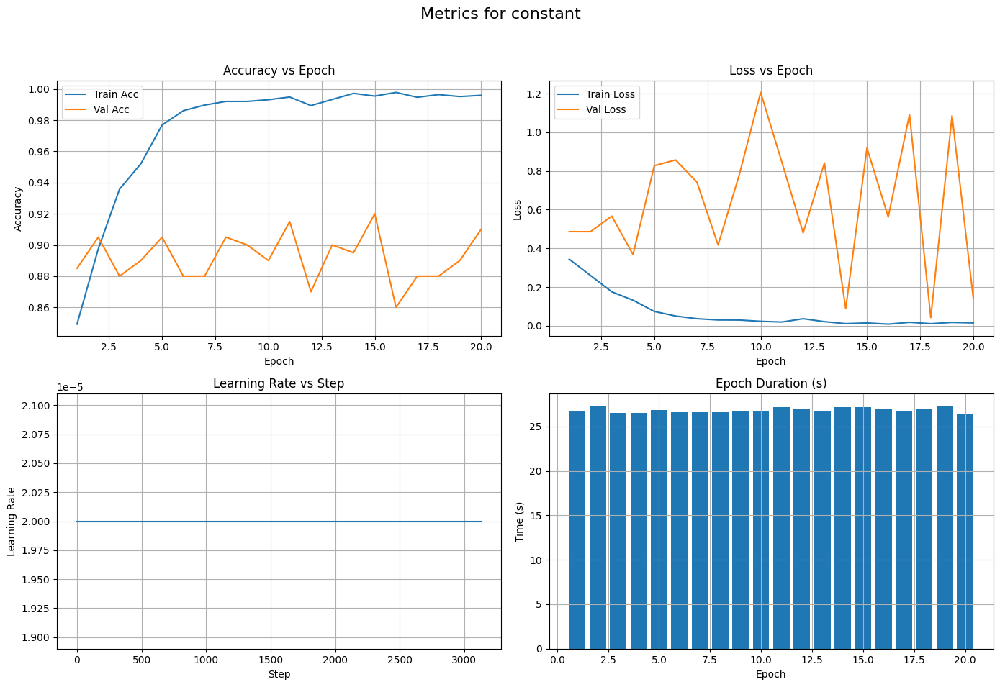

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/constant_grouped_metrics.png


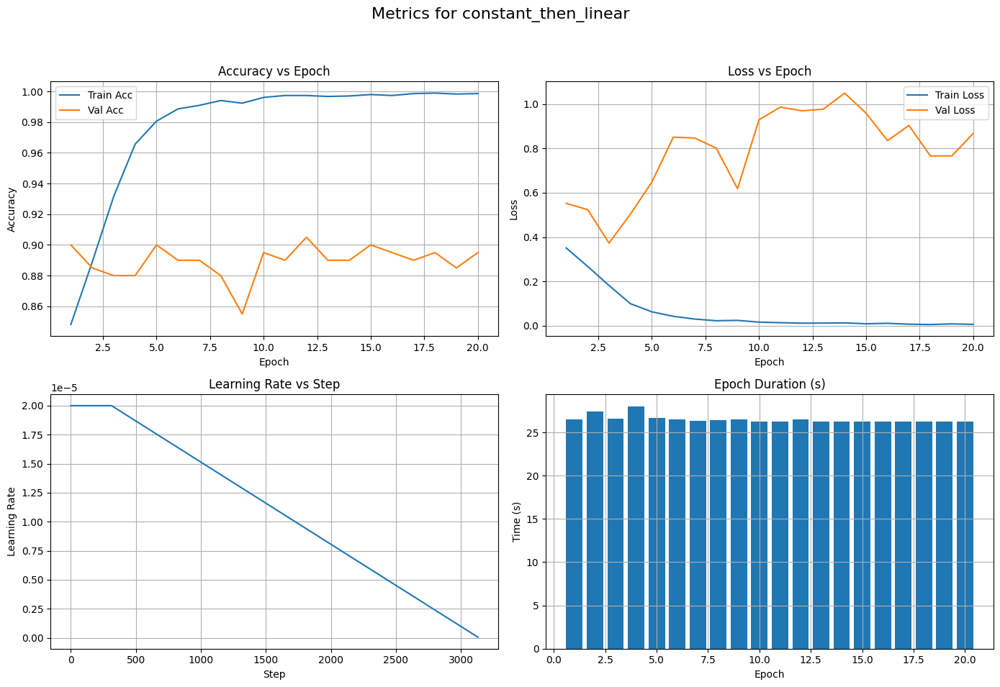

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/constant_then_linear_grouped_metrics.png


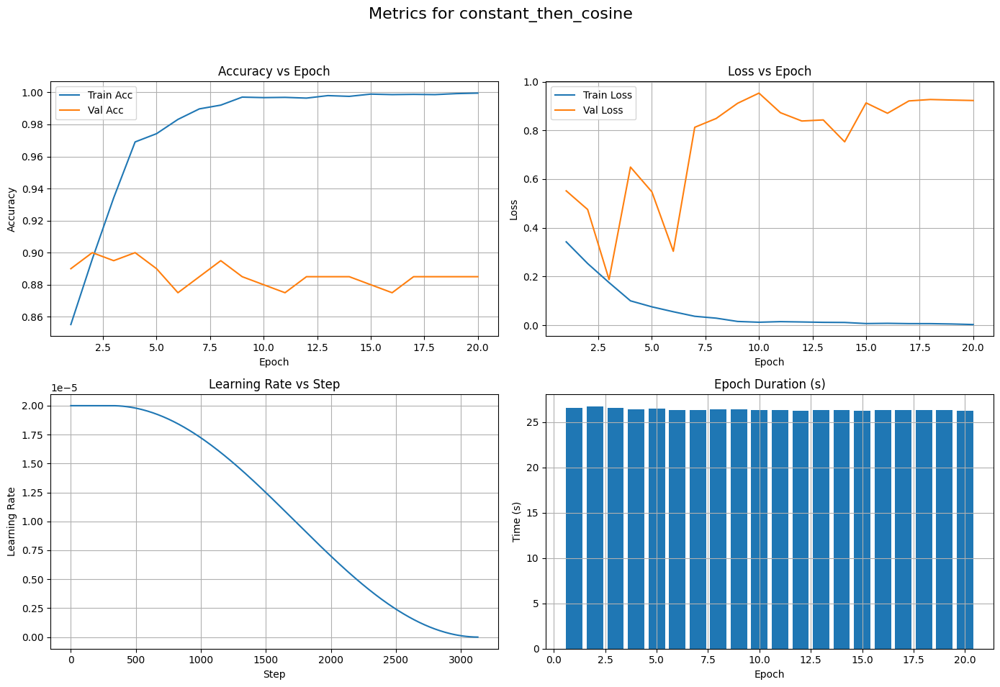

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/constant_then_cosine_grouped_metrics.png


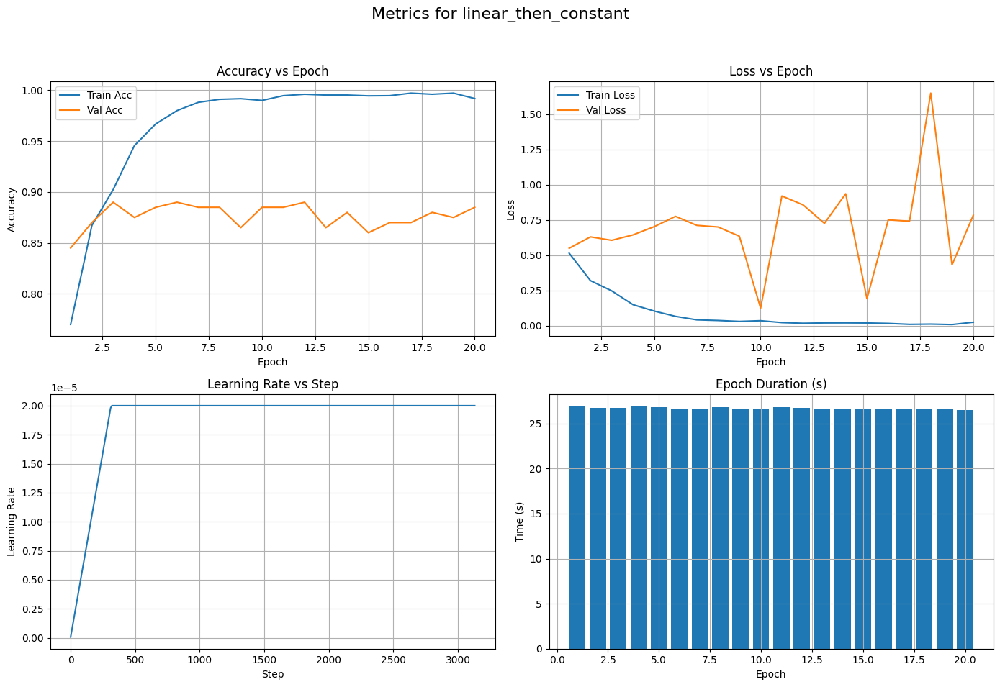

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/linear_then_constant_grouped_metrics.png


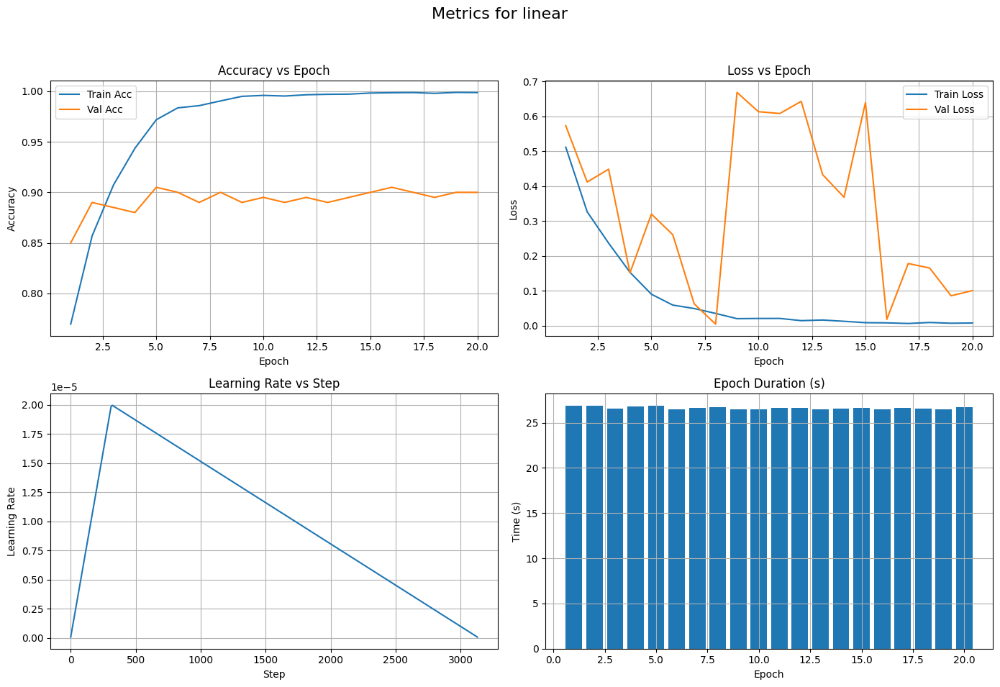

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/linear_grouped_metrics.png


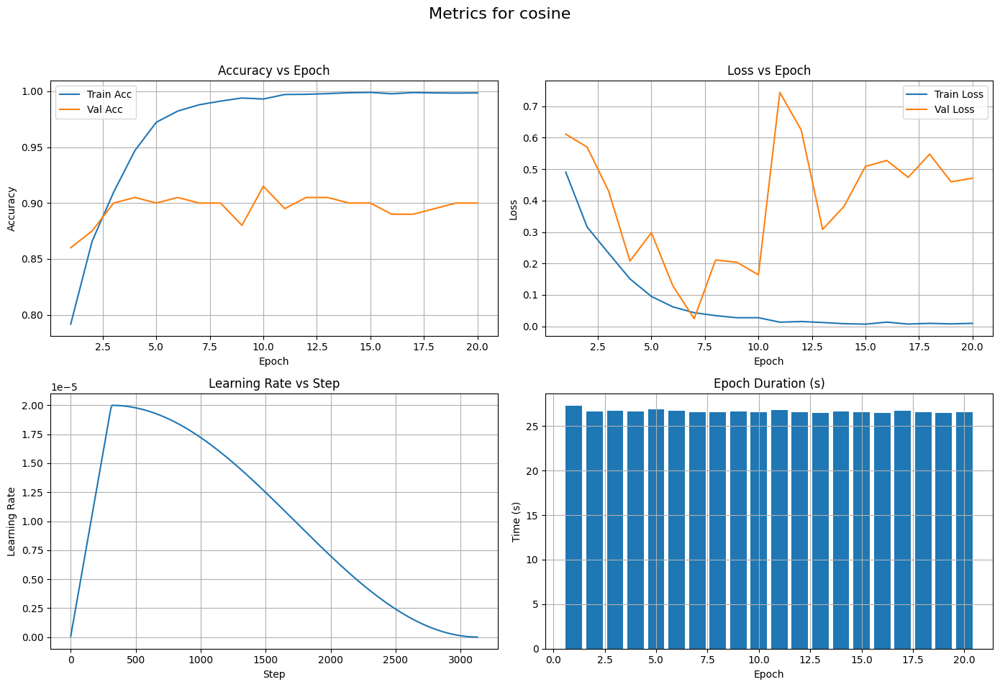

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/cosine_grouped_metrics.png


In [ ]:
scheduler_list = [
    "constant",
    "constant_then_linear",
    "constant_then_cosine",
    "linear_then_constant",
    "linear",
    "cosine"
]

plot_metrics_grouped(
    scheduler_names=scheduler_list,
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project",
    experiment_number=1
)


#### 1.2 รวมทุก Scheduler

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_experiment1_combined_metrics(scheduler_names, base_dir):
    """
    Plot combined metrics for Experiment 1.
    - Accuracy and Loss: show both train (dashed) and val (solid) lines, same color
    - LR and Epoch Time: normal plot
    """
    save_dir = os.path.join(base_dir, "graph", "exp1")
    os.makedirs(save_dir, exist_ok=True)

    fig, axs = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle("Combined Metrics for Experiment 1 (Train = dashed, Val = solid)", fontsize=16)

    colors = cm.get_cmap('tab10', len(scheduler_names))

    for i, sched in enumerate(scheduler_names):
        summary_path = os.path.join(base_dir, sched, f"training_summary_{sched}.csv")
        lr_log_path = os.path.join(base_dir, sched, f"lr_logs_{sched}.csv")

        if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
            print(f"⚠️ Missing data for: {sched}")
            continue

        df = pd.read_csv(summary_path)
        lr_df = pd.read_csv(lr_log_path)
        color = colors(i)

        # Accuracy
        axs[0, 0].plot(df['epoch'], df['val_acc'], label=f"{sched} (val)", color=color)
        axs[0, 0].plot(df['epoch'], df['train_acc'], linestyle='--', label=f"{sched} (train)", color=color)

        # Loss
        axs[0, 1].plot(df['epoch'], df['val_loss'], label=f"{sched} (val)", color=color)
        axs[0, 1].plot(df['epoch'], df['train_loss'], linestyle='--', label=f"{sched} (train)", color=color)

        # Learning Rate
        axs[1, 0].plot(lr_df['step'], lr_df['lr'], label=sched, color=color)

        # Time
        axs[1, 1].plot(df['epoch'], df['epoch_time'], label=sched, color=color)

    # Titles and labels
    axs[0, 0].set_title("Accuracy vs Epoch")
    axs[0, 1].set_title("Loss vs Epoch")
    axs[1, 0].set_title("Learning Rate vs Step")
    axs[1, 1].set_title("Epoch Duration (s)")

    for ax in axs.flat:
        ax.set_xlabel("Epoch" if "Epoch" in ax.get_title() else "Step")
        ax.legend(fontsize=8)
        ax.grid(True)

    axs[1, 0].set_xlabel("Step")
    axs[1, 1].set_xlabel("Epoch")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_path = os.path.join(save_dir, "combined_metrics.png")
    plt.savefig(save_path)
    plt.show()

    print(f"✅ Combined figure saved to: {save_path}")


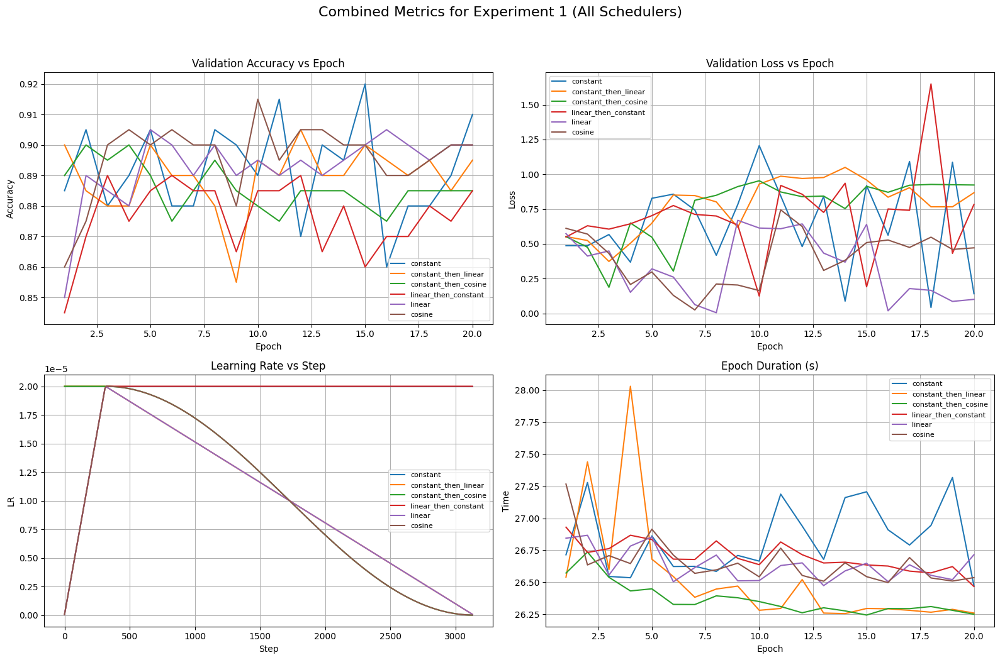

✅ Combined figure saved to: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/combined_metrics.png


In [ ]:
scheduler_list_exp1 = [
    "constant",
    "constant_then_linear",
    "constant_then_cosine",
    "linear_then_constant",
    "linear",
    "cosine"
]

plot_experiment1_combined_metrics(
    scheduler_names=scheduler_list_exp1,
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project"
)

In [ ]:
import os
import pandas as pd

def summarize_scheduler_with_self_avg(scheduler_names, base_dir, experiment_number):
    """
    Summarize metrics from training_summary of each scheduler.
    Includes both:
    - Best values (e.g., best validation accuracy)
    - Average values per scheduler (e.g., average validation accuracy over all epochs)
    """
    summary = []

    for scheduler in scheduler_names:
        summary_path = os.path.join(base_dir, scheduler, f"training_summary_{scheduler}.csv")

        df = pd.read_csv(summary_path)

        summary.append({
            "Scheduler": scheduler,
            "Best Val Acc": round(df['val_acc'].max(), 4),
            "Avg Val Acc": round(df['val_acc'].mean(), 4),
            "Final Val Loss": round(df['val_loss'].iloc[-1], 4),
            "Avg Val Loss": round(df['val_loss'].mean(), 4),
            "Best Train Acc": round(df['train_acc'].max(), 4),
            "Avg Train Acc": round(df['train_acc'].mean(), 4),
            "Total Time (s)": round(df['epoch_time'].sum(), 2),
            "Avg Epoch Time (s)": round(df['epoch_time'].mean(), 2)
        })

    result_df = pd.DataFrame(summary)
    save_dir = os.path.join(base_dir, "graph", f"exp{experiment_number}")
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(save_dir, f"summary_exp{experiment_number}_self_avg_only.csv")
    result_df.to_csv(csv_path, index=False)

    print(f"✅ Saved: {csv_path}")
    return result_df


In [ ]:
summary_df = summarize_scheduler_with_self_avg(
    scheduler_names=scheduler_list_exp1,
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project",
    experiment_number=1
)

summary_df


✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/summary_exp1_self_avg_only.csv


,Scheduler,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,constant,0.920,0.8920,0.1413,0.6418,0.9978,0.9757,536.76,26.84
1,constant_then_linear,0.890,0.8858,0.7058,0.6340,0.9980,0.9795,535.54,26.78
2,constant_then_cosine,0.900,0.8860,0.9228,0.7514,0.9995,0.9785,527.33,26.37
3,linear_then_constant,0.890,0.8768,0.7831,0.7030,0.9972,0.9673,533.99,26.70
4,linear,0.905,0.8928,0.1007,0.3378,0.9989,0.9689,532.69,26.63
5,cosine,0.915,0.8960,0.4711,0.3948,0.9991,0.9709,533.04,26.65


## 2 การทดลองที่ 1 : ปรับค่า Learning rate

#### 2.1 เปรียบเทียบผลลัพธ์ในแต่ละ Scheduler ที่ Learning rate ต่างกัน

In [ ]:
def plot_experiment2_combined_metrics_per_scheduler(scheduler_base_names, base_dir):
    """
    For each scheduler base name (e.g., 'linear_then_cosine'), load 3 learning rates:
    - scheduler_lr1e5, scheduler (assumed to be 2e-5), scheduler_lr4e5
    and plot them together (train = dashed, val = solid) on a single 2x2 grid.

    Saves each scheduler's combined graph to: /graph/exp2/{scheduler_name}_lr_compare.png
    """
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    save_dir = os.path.join(base_dir, "graph", "exp2")
    os.makedirs(save_dir, exist_ok=True)

    for base_name in scheduler_base_names:
        versions = [
            f"{base_name}_lr1e5",
            base_name,
            f"{base_name}_lr4e5"
        ]
        labels = ["LR 1e-5", "LR 2e-5", "LR 4e-5"]
        colors = cm.get_cmap("tab10", len(versions))

        fig, axs = plt.subplots(2, 2, figsize=(16, 11))
        fig.suptitle(f"Learning Rate Comparison for {base_name} (Train=Dashed, Val=Solid)", fontsize=16)

        for i, (version, label) in enumerate(zip(versions, labels)):
            summary_path = os.path.join(base_dir, version, f"training_summary_{version}.csv")
            lr_log_path = os.path.join(base_dir, version, f"lr_logs_{version}.csv")

            if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
                print(f"⚠️ Missing data for: {version}")
                continue

            df = pd.read_csv(summary_path)
            lr_df = pd.read_csv(lr_log_path)
            color = colors(i)

            # Accuracy
            axs[0, 0].plot(df['epoch'], df['val_acc'], label=f"{label} (val)", color=color)
            axs[0, 0].plot(df['epoch'], df['train_acc'], linestyle='--', label=f"{label} (train)", color=color)

            # Loss
            axs[0, 1].plot(df['epoch'], df['val_loss'], label=f"{label} (val)", color=color)
            axs[0, 1].plot(df['epoch'], df['train_loss'], linestyle='--', label=f"{label} (train)", color=color)

            # LR
            axs[1, 0].plot(lr_df['step'], lr_df['lr'], label=label, color=color)

            # Time
            axs[1, 1].plot(df['epoch'], df['epoch_time'], label=label, color=color)

        axs[0, 0].set_title("Accuracy vs Epoch")
        axs[0, 1].set_title("Loss vs Epoch")
        axs[1, 0].set_title("Learning Rate vs Step")
        axs[1, 1].set_title("Epoch Duration (s)")

        for ax in axs.flat:
            ax.set_xlabel("Epoch" if "Epoch" in ax.get_title() else "Step")
            ax.legend(fontsize=8)
            ax.grid(True)

        axs[1, 0].set_xlabel("Step")
        axs[1, 1].set_xlabel("Epoch")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        save_path = os.path.join(save_dir, f"{base_name}_lr_compare.png")
        plt.savefig(save_path)
        plt.show()

        print(f"✅ Saved: {save_path}")


<ipython-input-56-2e7801606bca>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


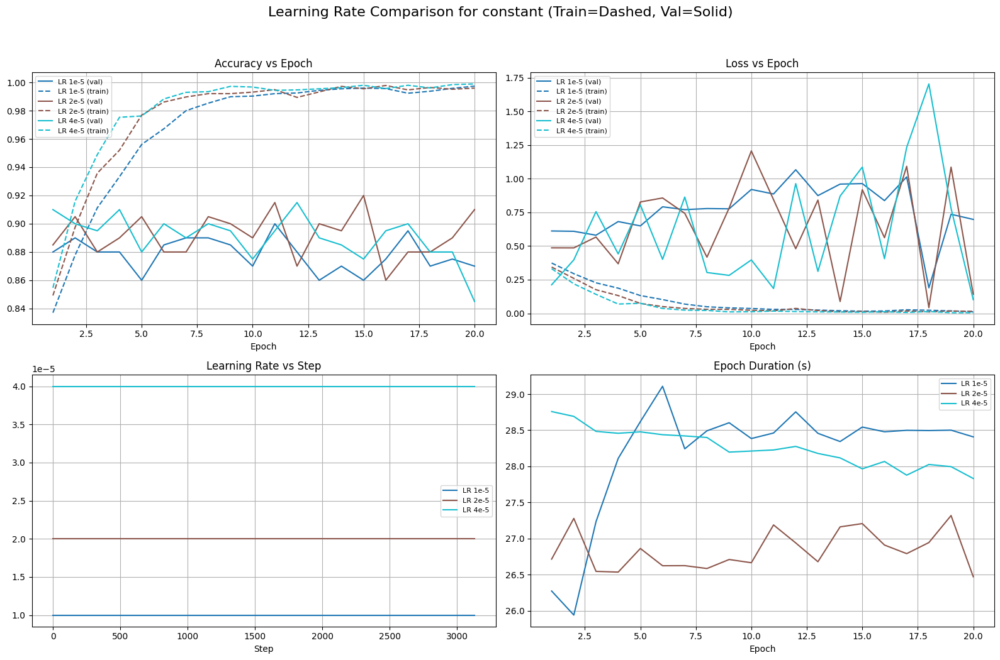

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/constant_lr_compare.png


<ipython-input-56-2e7801606bca>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


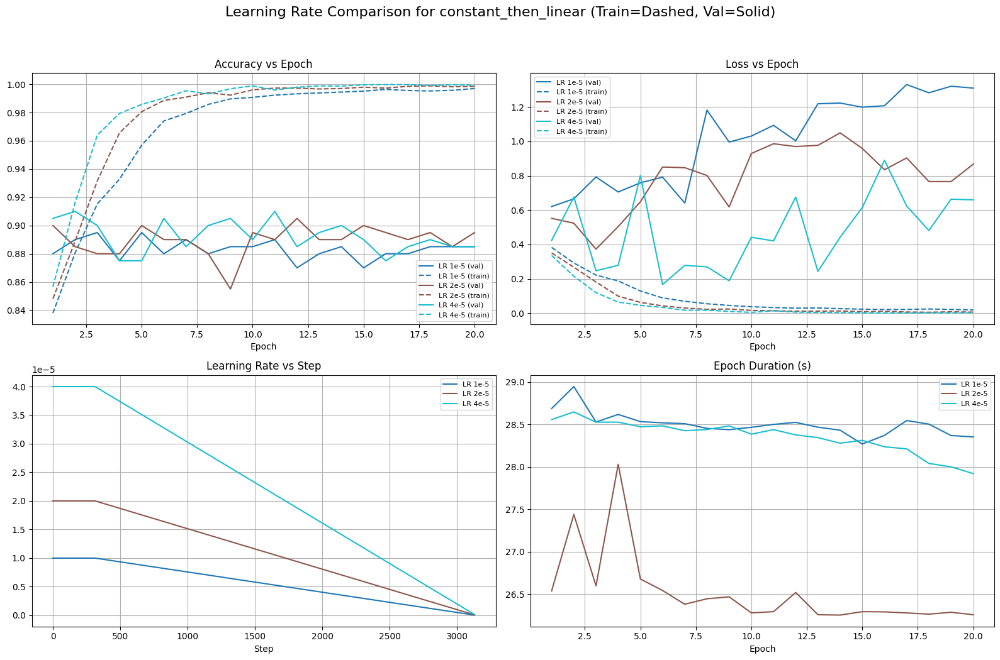

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/constant_then_linear_lr_compare.png


<ipython-input-56-2e7801606bca>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


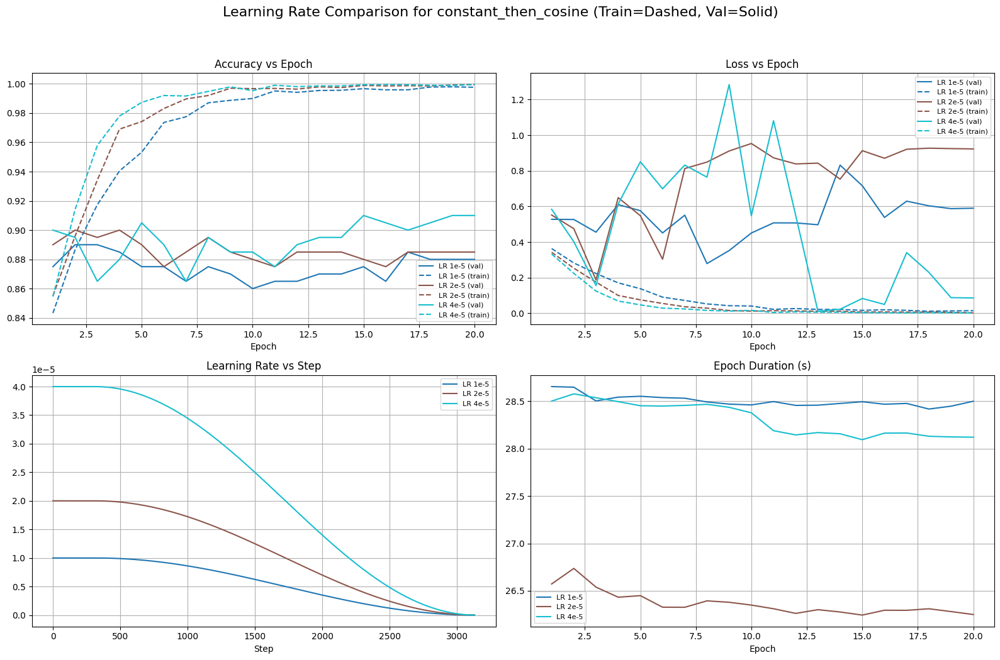

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/constant_then_cosine_lr_compare.png


<ipython-input-56-2e7801606bca>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


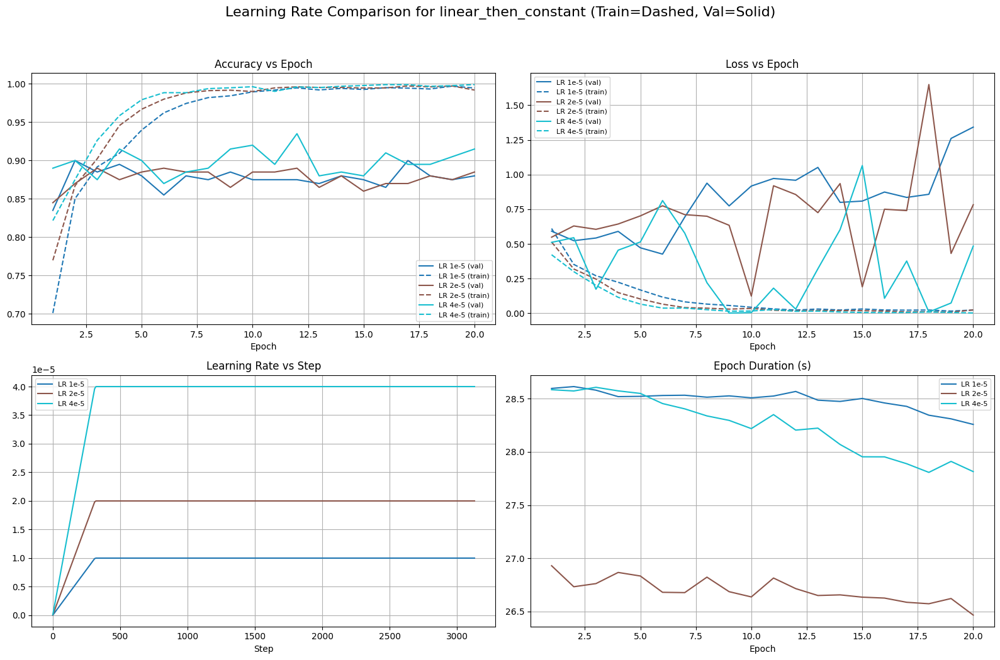

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/linear_then_constant_lr_compare.png


<ipython-input-56-2e7801606bca>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


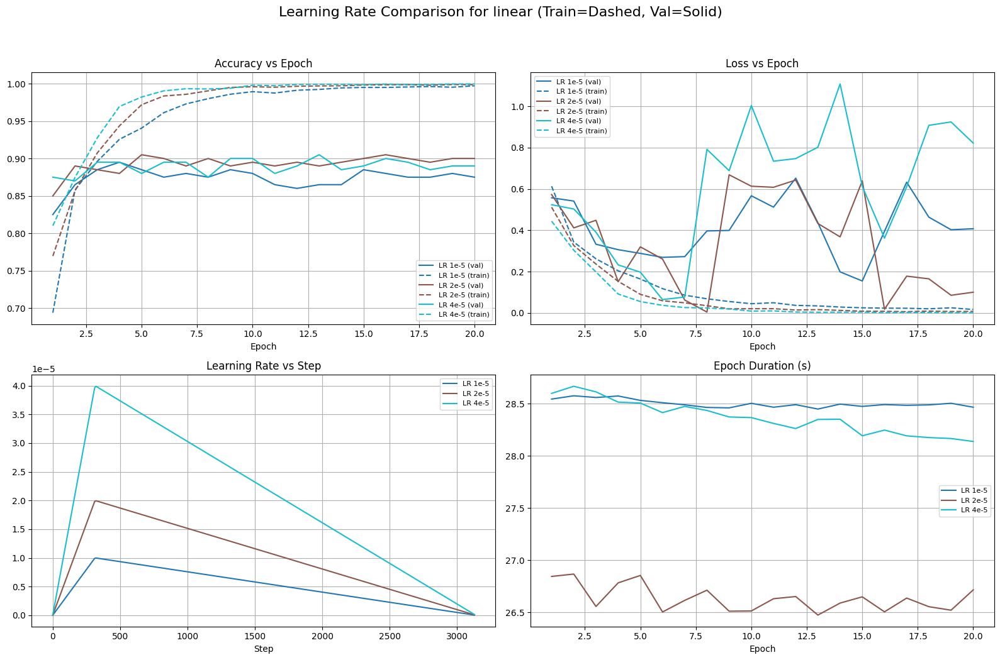

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/linear_lr_compare.png


<ipython-input-56-2e7801606bca>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


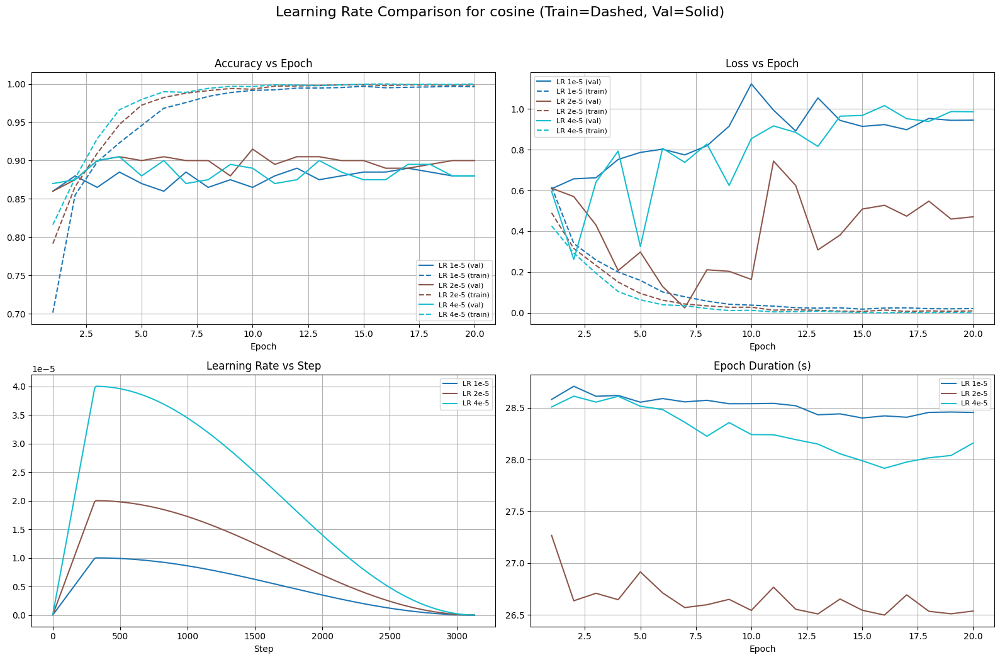

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/cosine_lr_compare.png


In [ ]:
scheduler_base_names_exp2 = [
    "constant",
    "constant_then_linear",
    "constant_then_cosine",
    "linear_then_constant",
    "linear",
    "cosine"
]

plot_experiment2_combined_metrics_per_scheduler(
    scheduler_base_names=scheduler_base_names_exp2,
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project"
)


#### 2.2 เปรียบเทียบ Scheduler แต่ละแบบใน learning rate เดียวกัน

In [18]:
def plot_experiment2_combined_metrics_per_lr(lr_versions, base_dir):
    """
    For each learning rate version (lr1e5, base/default, lr4e5),
    plot all 6 schedulers together in 1 image, with:
    - Accuracy & Loss: val (solid), train (dashed)
    - LR & Time: normal
    Moves legend outside to avoid overlap
    """
    save_dir = os.path.join(base_dir, "graph", "exp2")
    os.makedirs(save_dir, exist_ok=True)

    for lr_label, sched_names in lr_versions.items():
        fig, axs = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(f"All Schedulers Comparison at LR = {lr_label} (Train=Dashed, Val=Solid)", fontsize=16)

        colors = cm.get_cmap("tab10", len(sched_names))

        for i, sched in enumerate(sched_names):
            summary_path = os.path.join(base_dir, sched, f"training_summary_{sched}.csv")
            lr_log_path = os.path.join(base_dir, sched, f"lr_logs_{sched}.csv")

            if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
                print(f"⚠️ Missing data for: {sched}")
                continue

            df = pd.read_csv(summary_path)
            lr_df = pd.read_csv(lr_log_path)
            color = colors(i)

            axs[0, 0].plot(df['epoch'], df['val_acc'], label=f"{sched} (val)", color=color)
            axs[0, 0].plot(df['epoch'], df['train_acc'], linestyle='--', label=f"{sched} (train)", color=color)

            axs[0, 1].plot(df['epoch'], df['val_loss'], label=f"{sched} (val)", color=color)
            axs[0, 1].plot(df['epoch'], df['train_loss'], linestyle='--', label=f"{sched} (train)", color=color)

            axs[1, 0].plot(lr_df['step'], lr_df['lr'], label=sched, color=color)
            axs[1, 1].plot(df['epoch'], df['epoch_time'], label=sched, color=color)

        axs[0, 0].set_title("Accuracy vs Epoch")
        axs[0, 1].set_title("Loss vs Epoch")
        axs[1, 0].set_title("Learning Rate vs Step")
        axs[1, 1].set_title("Epoch Duration (s)")

        for ax in axs.flat:
            ax.set_xlabel("Epoch" if "Epoch" in ax.get_title() else "Step")
            ax.grid(True)
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

        axs[1, 0].set_xlabel("Step")
        axs[1, 1].set_xlabel("Epoch")

        plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
        save_path = os.path.join(save_dir, f"lr_{lr_label}_all_schedulers.png")
        plt.savefig(save_path, bbox_inches='tight')
        plt.show()

        print(f"✅ Saved: {save_path}")


<ipython-input-18-78f1763a278e>:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(sched_names))


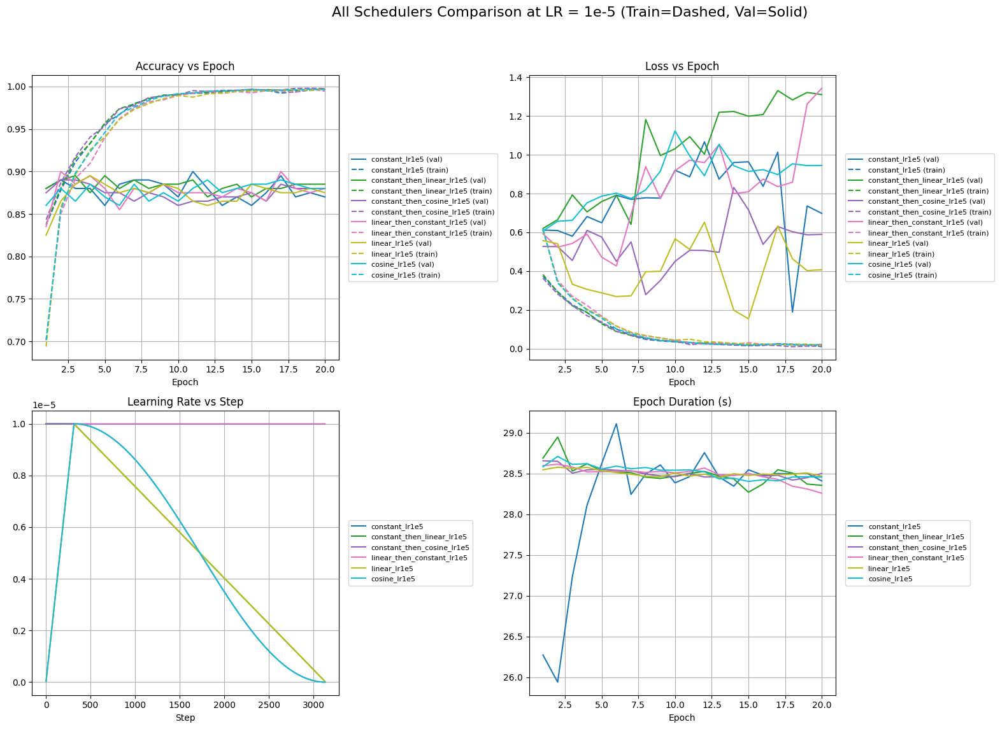

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/lr_1e-5_all_schedulers.png


<ipython-input-18-78f1763a278e>:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(sched_names))


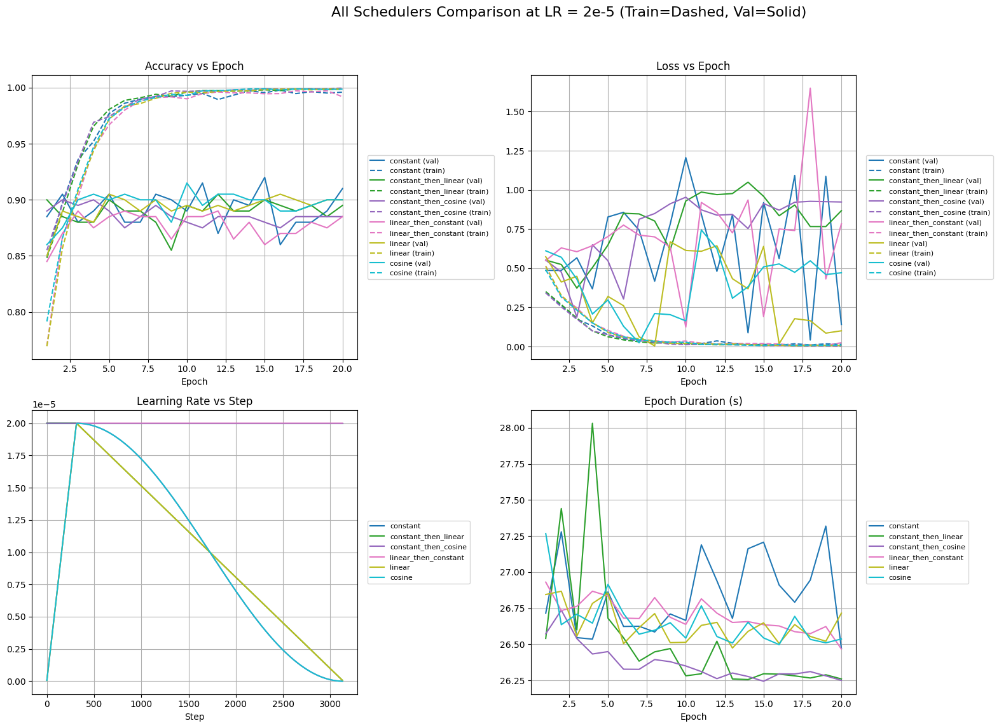

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/lr_2e-5_all_schedulers.png


<ipython-input-18-78f1763a278e>:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(sched_names))


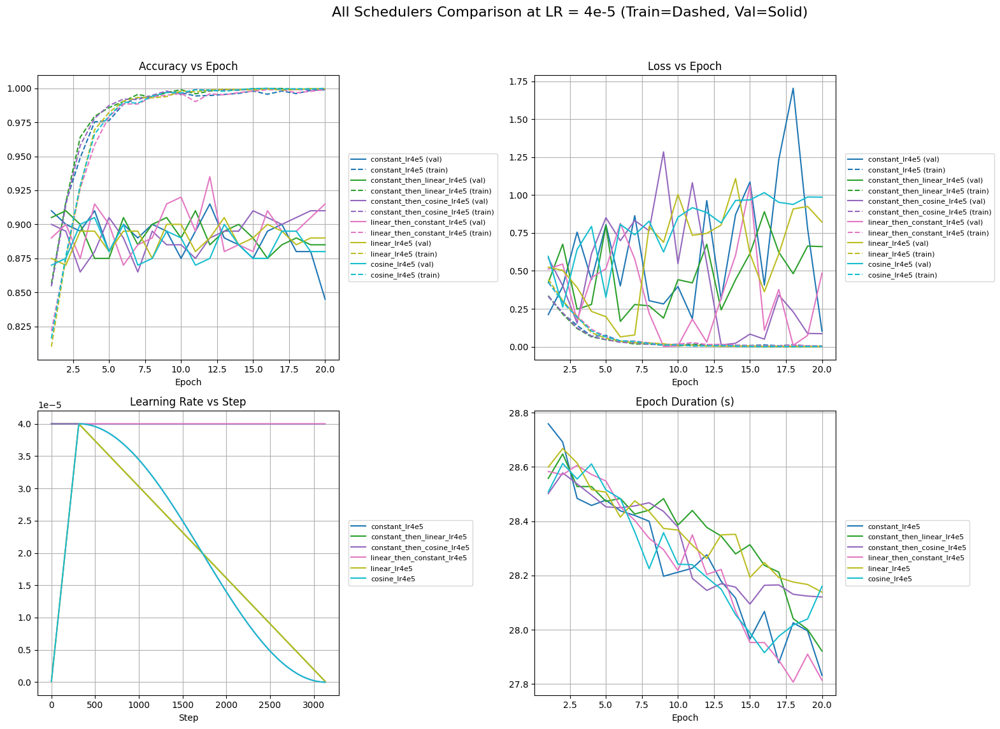

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp2/lr_4e-5_all_schedulers.png


In [19]:
lr_versions = {
    "1e-5": [
        "constant_lr1e5",
        "constant_then_linear_lr1e5",
        "constant_then_cosine_lr1e5",
        "linear_then_constant_lr1e5",
        "linear_lr1e5",
        "cosine_lr1e5"
    ],
    "2e-5": [
        "constant",
        "constant_then_linear",
        "constant_then_cosine",
        "linear_then_constant",
        "linear",
        "cosine"
    ],
    "4e-5": [
        "constant_lr4e5",
        "constant_then_linear_lr4e5",
        "constant_then_cosine_lr4e5",
        "linear_then_constant_lr4e5",
        "linear_lr4e5",
        "cosine_lr4e5"
    ]
}

plot_experiment2_combined_metrics_per_lr(
    lr_versions=lr_versions,
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project"
)


### 2.3 แสดงค่าแต่ละ Scheduler ออกมาเป็นตารางเปรียบเทียบระหว่าง Learning rate

In [35]:
import os
import pandas as pd

def summarize_and_split_per_scheduler(base_dir, experiment_number):
    schedulers = ["constant", "constant_then_linear", "constant_then_cosine",
                  "linear_then_constant", "linear", "cosine"]

    lr_versions = {
        "LR 1e-5": "_lr1e5",
        "LR 2e-5": "",          # default (no suffix)
        "LR 4e-5": "_lr4e5"
    }

    save_dir = os.path.join(base_dir, "graph", f"exp{experiment_number}", "split_by_scheduler")
    os.makedirs(save_dir, exist_ok=True)

    all_results = {}

    for sched in schedulers:
        records = []
        for label, suffix in lr_versions.items():
            sched_name = f"{sched}{suffix}"
            summary_path = os.path.join(base_dir, sched_name, f"training_summary_{sched_name}.csv")

            if not os.path.exists(summary_path):
                print(f"⚠️ Missing: {summary_path}")
                continue

            df = pd.read_csv(summary_path)
            records.append({
                "LR Version": label,
                "Best Val Acc": round(df['val_acc'].max(), 4),
                "Avg Val Acc": round(df['val_acc'].mean(), 4),
                "Final Val Loss": round(df['val_loss'].iloc[-1], 4),
                "Avg Val Loss": round(df['val_loss'].mean(), 4),
                "Best Train Acc": round(df['train_acc'].max(), 4),
                "Avg Train Acc": round(df['train_acc'].mean(), 4),
                "Total Time (s)": round(df['epoch_time'].sum(), 2),
                "Avg Epoch Time (s)": round(df['epoch_time'].mean(), 2)
            })

        df_result = pd.DataFrame(records)
        csv_path = os.path.join(save_dir, f"{sched}_summary.csv")
        df_result.to_csv(csv_path, index=False)
        all_results[sched] = df_result
        print(f"✅ Saved: {csv_path}")

    return all_results

base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
experiment_number = 1

scheduler_tables = summarize_and_split_per_scheduler(
    base_dir=base_dir,
    experiment_number=experiment_number
)



✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/split_by_scheduler/constant_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/split_by_scheduler/constant_then_linear_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/split_by_scheduler/constant_then_cosine_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/split_by_scheduler/linear_then_constant_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/split_by_scheduler/linear_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp1/split_by_scheduler/cosine_summary.csv


In [28]:
scheduler_tables["constant"]

,LR Version,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,LR 1e-5,0.900,0.8782,0.6977,0.7697,0.9973,0.9687,563.95,28.20
1,LR 2e-5,0.920,0.8920,0.1413,0.6418,0.9978,0.9757,536.76,26.84
2,LR 4e-5,0.915,0.8908,0.1015,0.6249,0.9989,0.9803,565.10,28.26


In [36]:
scheduler_tables["constant_then_linear"]

,LR Version,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,LR 1e-5,0.895,0.8832,1.3099,1.0185,0.9970,0.9696,570.05,28.50
1,LR 2e-5,0.905,0.8895,0.8673,0.7863,0.9989,0.9778,530.43,26.52
2,LR 4e-5,0.910,0.8925,0.6599,0.4743,0.9998,0.9833,567.12,28.36


In [37]:
scheduler_tables["constant_then_cosine"]

,LR Version,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,LR 1e-5,0.89,0.8748,0.5899,0.5394,0.9980,0.9710,570.09,28.50
1,LR 2e-5,0.90,0.8860,0.9228,0.7514,0.9995,0.9785,527.33,26.37
2,LR 4e-5,0.91,0.8930,0.0859,0.4638,0.9995,0.9827,566.22,28.31


In [38]:
scheduler_tables["linear_then_constant"]

,LR Version,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,LR 1e-5,0.900,0.8770,1.3425,0.8119,0.9970,0.9562,569.78,28.49
1,LR 2e-5,0.890,0.8768,0.7831,0.7030,0.9972,0.9673,533.99,26.70
2,LR 4e-5,0.935,0.8978,0.4847,0.3537,0.9991,0.9745,564.76,28.24


In [39]:
scheduler_tables["linear"]

,LR Version,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,LR 1e-5,0.895,0.8738,0.4078,0.4095,0.9972,0.9572,570.04,28.50
1,LR 2e-5,0.905,0.8928,0.1007,0.3378,0.9989,0.9689,532.69,26.63
2,LR 4e-5,0.905,0.8895,0.8220,0.6054,0.9997,0.9761,567.36,28.37


In [40]:
scheduler_tables["cosine"]

,LR Version,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,LR 1e-5,0.890,0.8770,0.9448,0.8680,0.9969,0.9593,570.42,28.52
1,LR 2e-5,0.915,0.8960,0.4711,0.3948,0.9991,0.9709,533.04,26.65
2,LR 4e-5,0.905,0.8845,0.9860,0.7948,1.0000,0.9763,565.21,28.26


## 3 การทดลองที่ 2 : ปรับจำนวน Step ในการ Warm up

### 3.1 เปรียบเทียบผลลัพธ์ในแต่ละ Scheduler ที่ Warm up step ต่างกัน

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_exp3_warmup_comparison_per_scheduler(scheduler_base_names, base_dir):
    """
    For each scheduler base name (e.g., 'linear'), load 3 warm-up versions:
    - warm0, warm10 (default), warm20
    Plot them together on a single 2x2 grid:
    - Accuracy (val/solid, train/dashed)
    - Loss (val/solid, train/dashed)
    - LR, Time (normal)
    Saves to: /graph/exp3/{scheduler_name}_warmup_compare.png
    """
    save_dir = os.path.join(base_dir, "graph", "exp3")
    os.makedirs(save_dir, exist_ok=True)

    for base_name in scheduler_base_names:
        # Determine actual folder names
        if base_name in ["constant", "linear_then_constant"]:
            warmup0 = "constant_warm0"
        elif base_name in ["linear", "constant_then_linear"]:
            warmup0 = "linear_warm0"
        elif base_name in ["cosine", "constant_then_cosine"]:
            warmup0 = "cosine_warm0"
        else:
            warmup0 = f"{base_name}_warm0"

        warmup10 = base_name
        warmup20 = "constant" if base_name == "constant" else f"{base_name}_warm20"


        versions = [warmup0, warmup10, warmup20]
        labels = ["Warm-up 0%", "Warm-up 10%", "Warm-up 20%"]
        colors = cm.get_cmap("tab10", len(versions))

        fig, axs = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(f"Warm-up Comparison for {base_name} (Train=Dashed, Val=Solid)", fontsize=16)

        for i, (folder, label) in enumerate(zip(versions, labels)):
            summary_path = os.path.join(base_dir, folder, f"training_summary_{folder}.csv")
            lr_log_path = os.path.join(base_dir, folder, f"lr_logs_{folder}.csv")

            if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
                print(f"⚠️ Missing data for: {folder}")
                continue

            df = pd.read_csv(summary_path)
            lr_df = pd.read_csv(lr_log_path)
            color = colors(i)

            # Accuracy
            axs[0, 0].plot(df['epoch'], df['val_acc'], label=f"{label} (val)", color=color)
            axs[0, 0].plot(df['epoch'], df['train_acc'], linestyle='--', label=f"{label} (train)", color=color)

            # Loss
            axs[0, 1].plot(df['epoch'], df['val_loss'], label=f"{label} (val)", color=color)
            axs[0, 1].plot(df['epoch'], df['train_loss'], linestyle='--', label=f"{label} (train)", color=color)

            # LR
            axs[1, 0].plot(lr_df['step'], lr_df['lr'], label=label, color=color)

            # Time
            axs[1, 1].plot(df['epoch'], df['epoch_time'], label=label, color=color)

        axs[0, 0].set_title("Accuracy vs Epoch")
        axs[0, 1].set_title("Loss vs Epoch")
        axs[1, 0].set_title("Learning Rate vs Step")
        axs[1, 1].set_title("Epoch Duration (s)")

        for ax in axs.flat:
            ax.set_xlabel("Epoch" if "Epoch" in ax.get_title() else "Step")
            ax.grid(True)
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

        axs[1, 0].set_xlabel("Step")
        axs[1, 1].set_xlabel("Epoch")

        plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
        save_path = os.path.join(save_dir, f"{base_name}_warmup_compare.png")
        plt.savefig(save_path, bbox_inches='tight')
        plt.show()

        print(f"✅ Saved: {save_path}")


<ipython-input-33-00851902e17d>:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


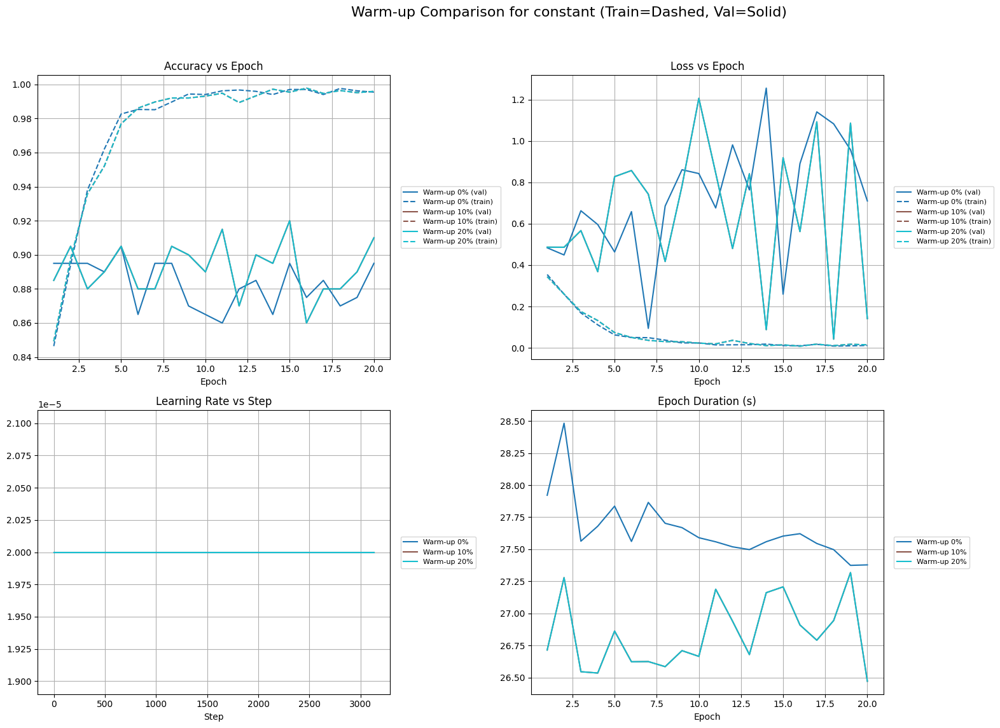

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/constant_warmup_compare.png


<ipython-input-33-00851902e17d>:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


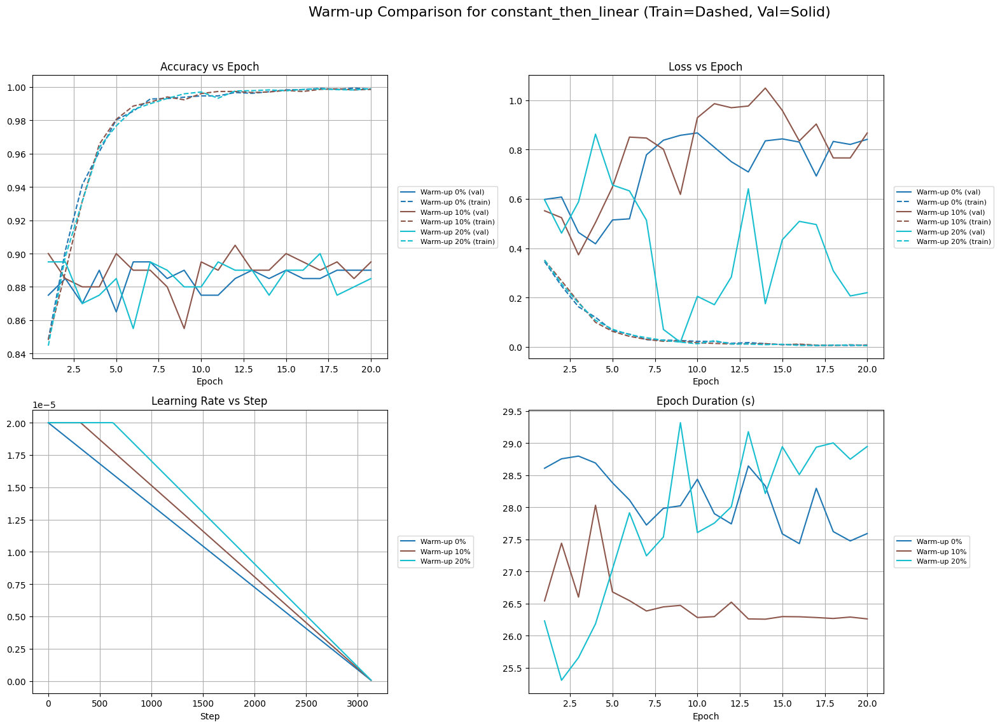

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/constant_then_linear_warmup_compare.png


<ipython-input-33-00851902e17d>:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


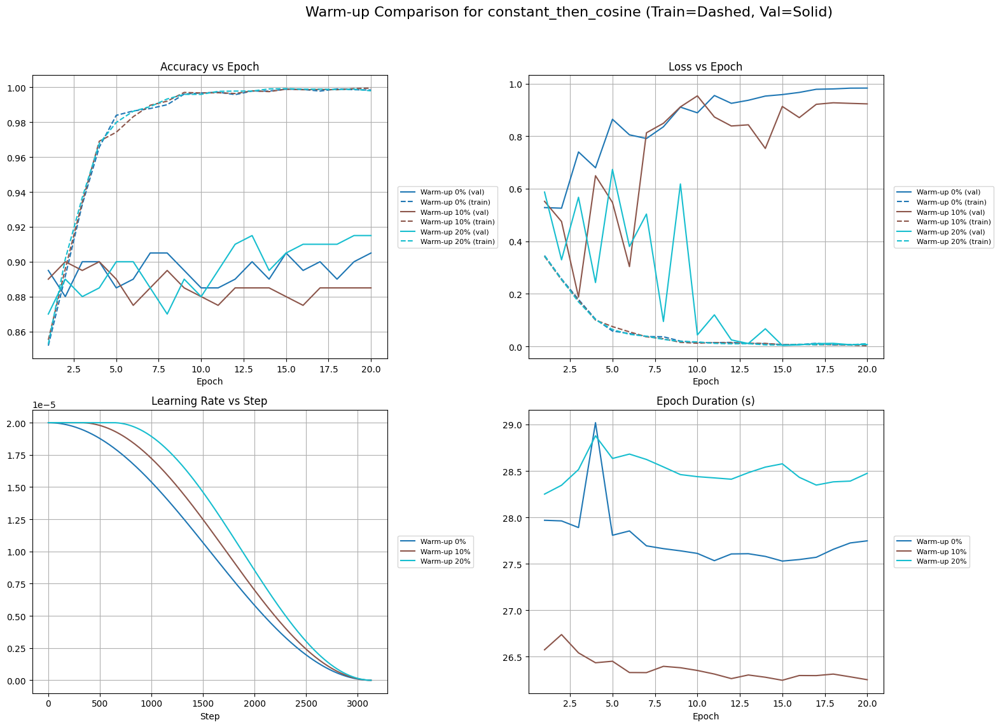

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/constant_then_cosine_warmup_compare.png


<ipython-input-33-00851902e17d>:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


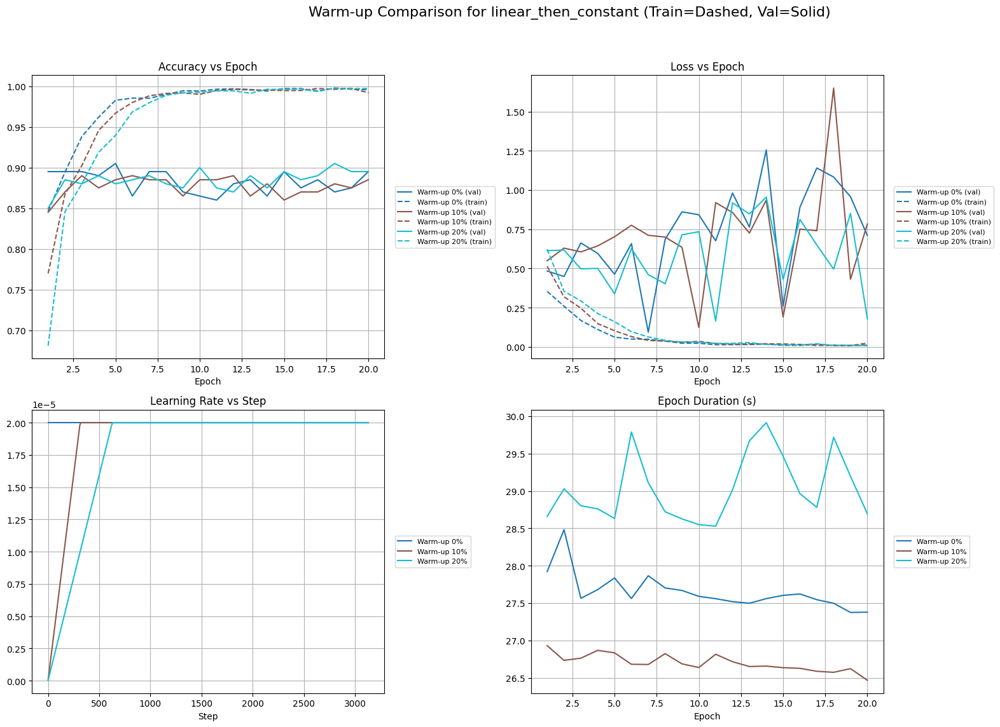

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/linear_then_constant_warmup_compare.png


<ipython-input-33-00851902e17d>:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


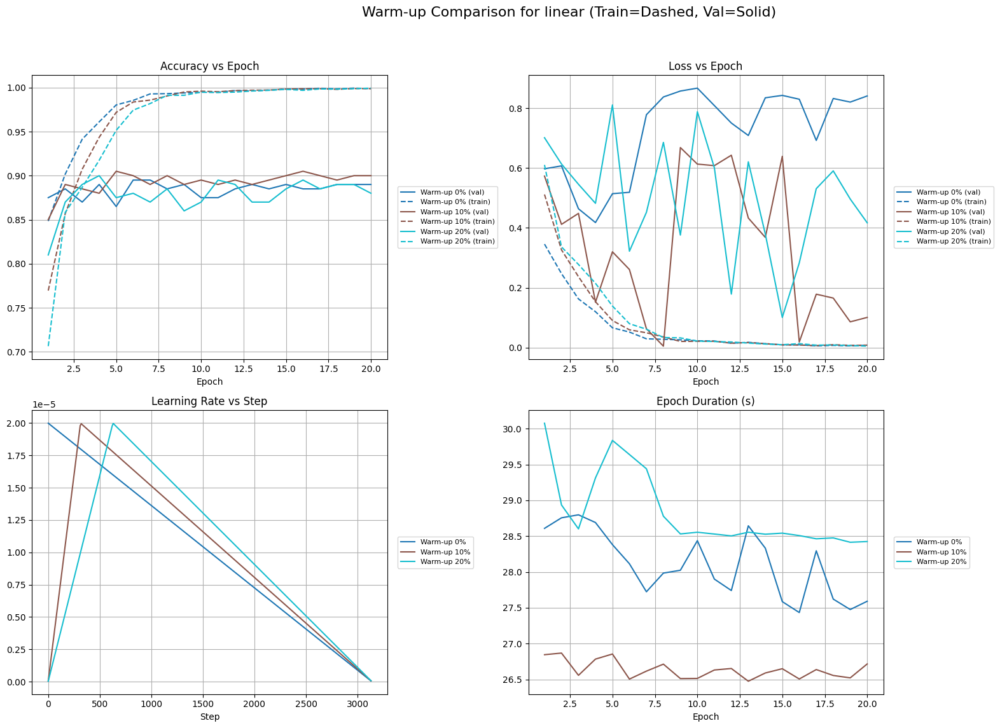

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/linear_warmup_compare.png


<ipython-input-33-00851902e17d>:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(versions))


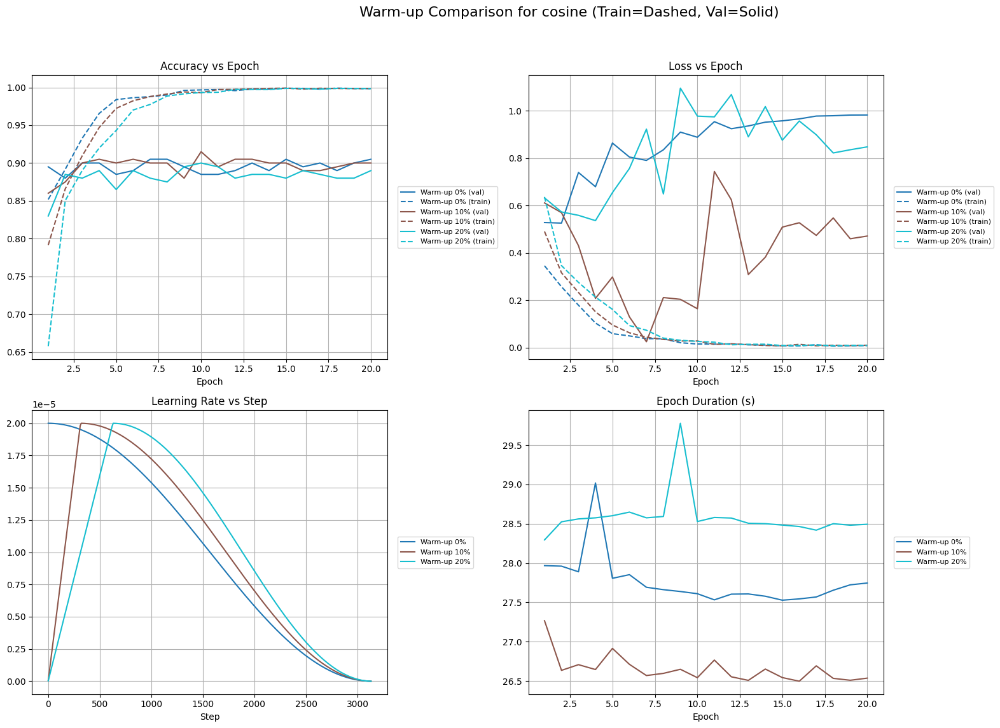

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/cosine_warmup_compare.png


In [34]:
plot_exp3_warmup_comparison_per_scheduler(
    scheduler_base_names=[
        "constant",
        "constant_then_linear",
        "constant_then_cosine",
        "linear_then_constant",
        "linear",
        "cosine"
    ],
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project"
)


### 3.2 เปรียบเทียบ Scheduler แต่ละแบบใน learning rate เดียวกัน

In [15]:
def plot_experiment3_metrics_separate_per_warmup(base_dir, warmup_versions):
    """
    Plot Experiment 3 by warmup group (0%, 10%, 20%) separately.
    Each plot shows all schedulers for that warmup group with:
    - Accuracy (val = solid, train = dashed)
    - Loss (val = solid, train = dashed)
    - LR and Time (normal)
    """
    save_dir = os.path.join(base_dir, "graph", "exp3")
    os.makedirs(save_dir, exist_ok=True)

    for warmup_label, sched_names in warmup_versions.items():
        fig, axs = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(f"Schedulers with Warm-up {warmup_label.replace('warm', '')}%", fontsize=16)

        import matplotlib.cm as cm
        colors = cm.get_cmap("tab10", len(sched_names))

        for i, sched in enumerate(sched_names):
            summary_path = os.path.join(base_dir, sched, f"training_summary_{sched}.csv")
            lr_log_path = os.path.join(base_dir, sched, f"lr_logs_{sched}.csv")

            if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
                print(f"⚠️ Missing data for: {sched}")
                continue

            df = pd.read_csv(summary_path)
            lr_df = pd.read_csv(lr_log_path)
            color = colors(i)

            axs[0, 0].plot(df['epoch'], df['val_acc'], label=f"{sched} (val)", color=color)
            axs[0, 0].plot(df['epoch'], df['train_acc'], linestyle='--', label=f"{sched} (train)", color=color)

            axs[0, 1].plot(df['epoch'], df['val_loss'], label=f"{sched} (val)", color=color)
            axs[0, 1].plot(df['epoch'], df['train_loss'], linestyle='--', label=f"{sched} (train)", color=color)

            axs[1, 0].plot(lr_df['step'], lr_df['lr'], label=sched, color=color)
            axs[1, 1].plot(df['epoch'], df['epoch_time'], label=sched, color=color)

        axs[0, 0].set_title("Accuracy vs Epoch")
        axs[0, 1].set_title("Loss vs Epoch")
        axs[1, 0].set_title("Learning Rate vs Step")
        axs[1, 1].set_title("Epoch Duration (s)")

        for ax in axs.flat:
            ax.set_xlabel("Epoch" if "Epoch" in ax.get_title() else "Step")
            ax.grid(True)
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

        axs[1, 0].set_xlabel("Step")
        axs[1, 1].set_xlabel("Epoch")

        plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
        save_path = os.path.join(save_dir, f"warmup_{warmup_label}.png")
        plt.savefig(save_path, bbox_inches='tight')
        plt.show()

        print(f"✅ Saved: {save_path}")


<ipython-input-15-06cd626073b0>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(sched_names))


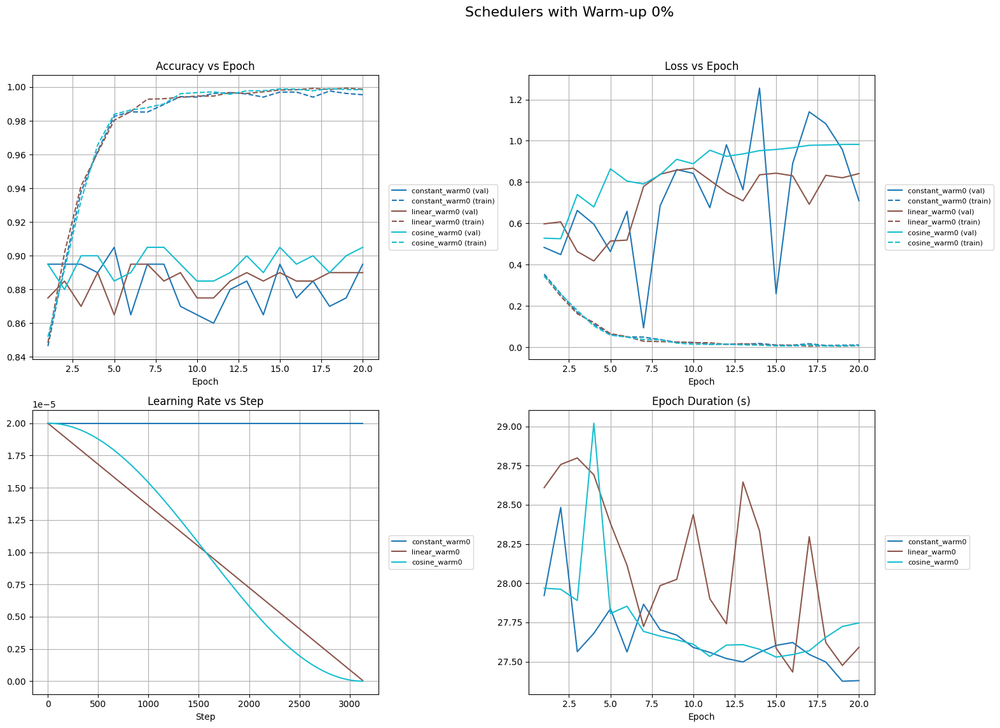

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/warmup_warm0.png


<ipython-input-15-06cd626073b0>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(sched_names))


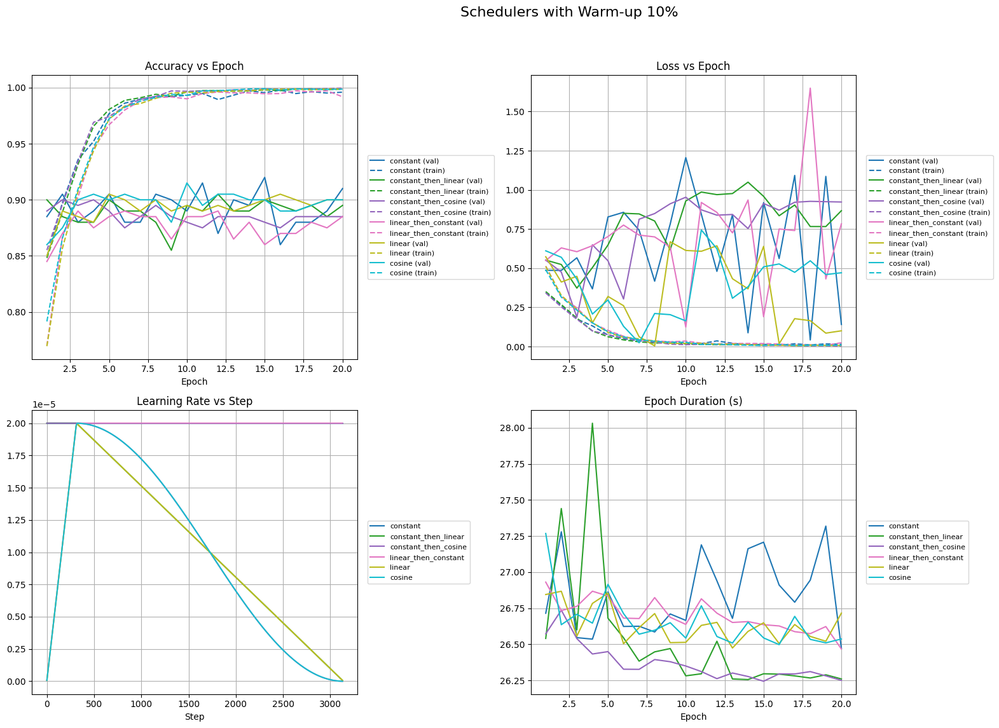

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/warmup_warm10.png


<ipython-input-15-06cd626073b0>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(sched_names))


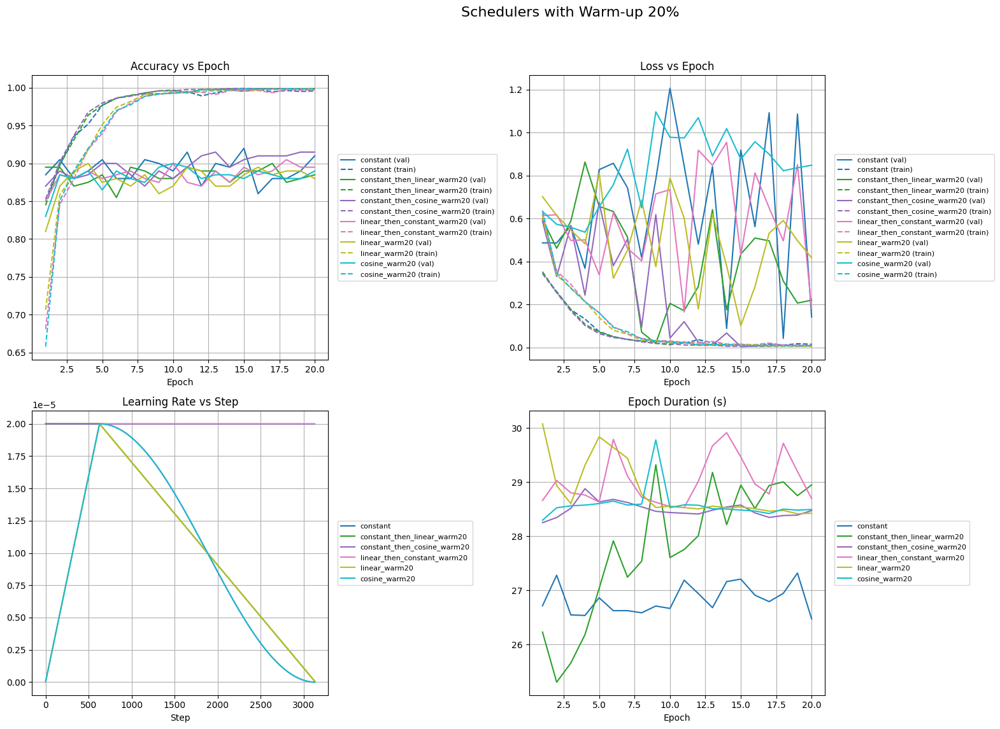

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/warmup_warm20.png


In [16]:
warmup_versions = {
    "warm0": [
        "constant_warm0",
        "linear_warm0",
        "cosine_warm0"
    ],
    "warm10": [
        "constant",
        "constant_then_linear",
        "constant_then_cosine",
        "linear_then_constant",
        "linear",
        "cosine"
    ],
    "warm20": [
        "constant",
        "constant_then_linear_warm20",
        "constant_then_cosine_warm20",
        "linear_then_constant_warm20",
        "linear_warm20",
        "cosine_warm20"
    ]
}

plot_experiment3_metrics_separate_per_warmup(
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project",
    warmup_versions=warmup_versions
)


### 3.3 รวมทุก Scheduler และ Learning rate

In [13]:
def plot_experiment3_combined_metrics_warmup(base_dir, warmup_versions):
    """
    Same as previous, but expands figure size and layout space to avoid compression.
    """
    save_dir = os.path.join(base_dir, "graph", "exp3")
    os.makedirs(save_dir, exist_ok=True)

    fig, axs = plt.subplots(2, 2, figsize=(20, 13))  # wider and taller
    fig.suptitle("All Schedulers Comparison across Warm-up Ratios (Train=Dashed, Val=Solid)", fontsize=18)

    total_curves = sum(len(scheds) for scheds in warmup_versions.values())
    colors = cm.get_cmap("tab10", total_curves)

    idx = 0
    for warmup_label, sched_names in warmup_versions.items():
        for sched in sched_names:
            summary_path = os.path.join(base_dir, sched, f"training_summary_{sched}.csv")
            lr_log_path = os.path.join(base_dir, sched, f"lr_logs_{sched}.csv")

            if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
                print(f"⚠️ Missing data for: {sched}")
                continue

            df = pd.read_csv(summary_path)
            lr_df = pd.read_csv(lr_log_path)
            color = colors(idx % 10)
            label = f"{sched} (val)"

            axs[0, 0].plot(df['epoch'], df['val_acc'], label=label, color=color)
            axs[0, 0].plot(df['epoch'], df['train_acc'], linestyle='--', label=f"{sched} (train)", color=color)

            axs[0, 1].plot(df['epoch'], df['val_loss'], label=label, color=color)
            axs[0, 1].plot(df['epoch'], df['train_loss'], linestyle='--', label=f"{sched} (train)", color=color)

            axs[1, 0].plot(lr_df['step'], lr_df['lr'], label=sched, color=color)
            axs[1, 1].plot(df['epoch'], df['epoch_time'], label=sched, color=color)

            idx += 1

    axs[0, 0].set_title("Accuracy vs Epoch")
    axs[0, 1].set_title("Loss vs Epoch")
    axs[1, 0].set_title("Learning Rate vs Step")
    axs[1, 1].set_title("Epoch Duration (s)")

    for ax in axs.flat:
        ax.set_xlabel("Epoch" if "Epoch" in ax.get_title() else "Step")
        ax.grid(True)
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

    axs[1, 0].set_xlabel("Step")
    axs[1, 1].set_xlabel("Epoch")

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
    save_path = os.path.join(save_dir, "combined_metrics_all_warmups_wide.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f"✅ Saved: {save_path}")


<ipython-input-13-ef8c8727b05a>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", total_curves)


⚠️ Missing data for: constant_warm20


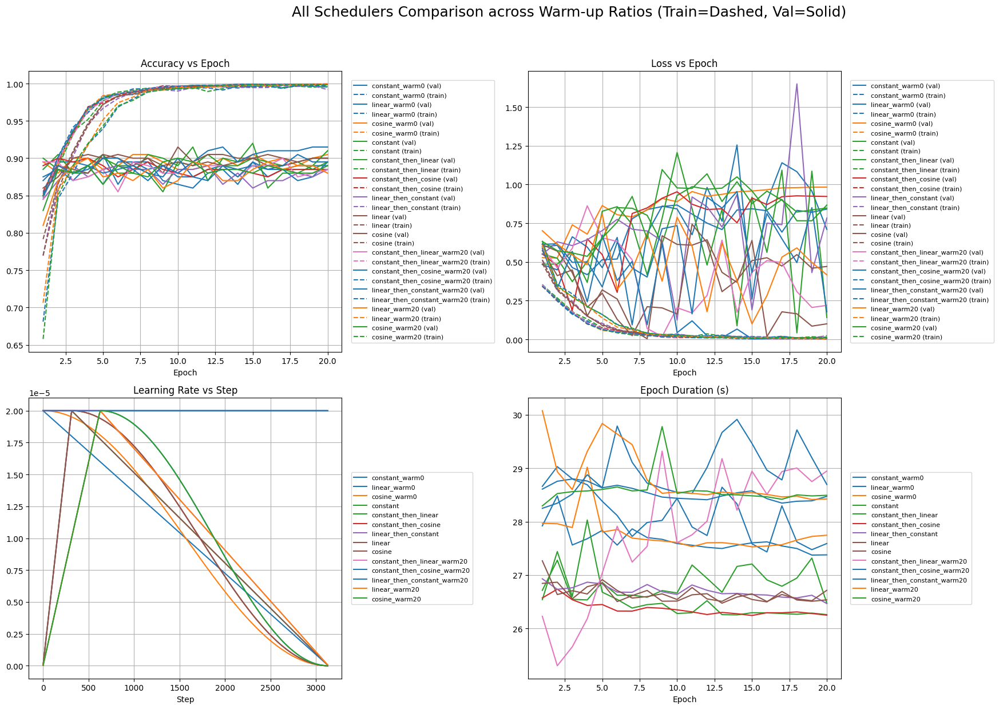

✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/combined_metrics_all_warmups_wide.png


In [14]:
warmup_versions = {
    "warm0": [
        "constant_warm0" ,
        "linear_warm0",
        "cosine_warm0"
    ],
    "warm10": [
         "constant",
        "constant_then_linear",
        "constant_then_cosine",
        "linear_then_constant",
        "linear",
        "cosine"
    ],
    "warm20": [
        "constant_warm20", "constant_then_linear_warm20", "constant_then_cosine_warm20",
        "linear_then_constant_warm20", "linear_warm20", "cosine_warm20"
    ]
}

plot_experiment3_combined_metrics_warmup(
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project",
    warmup_versions=warmup_versions
)

### 3.4 แสดงค่าแต่ละ Scheduler ออกมาเป็นตารางเปรียบเทียบระหว่าง Warm up

In [42]:
import os
import pandas as pd

def summarize_warmup_split_per_scheduler(base_dir, experiment_number):
    schedulers = ["constant", "constant_then_linear", "constant_then_cosine",
                  "linear_then_constant", "linear", "cosine"]

    warmup_versions = {
        "Warm-up 0%": {
            "constant": "constant_warm0",
            "linear_then_constant": "constant_warm0",
            "linear": "linear_warm0",
            "constant_then_linear": "linear_warm0",
            "cosine": "cosine_warm0",
            "constant_then_cosine": "cosine_warm0"
        },
        "Warm-up 10%": {},  # default = scheduler name itself
        "Warm-up 20%": {
            "constant": "constant",  # special case
            "linear_then_constant": "linear_then_constant_warm20",
            "linear": "linear_warm20",
            "constant_then_linear": "constant_then_linear_warm20",
            "cosine": "cosine_warm20",
            "constant_then_cosine": "constant_then_cosine_warm20"
        }
    }

    save_dir = os.path.join(base_dir, "graph", f"exp{experiment_number}", "split_by_scheduler")
    os.makedirs(save_dir, exist_ok=True)

    all_results = {}

    for sched in schedulers:
        records = []
        for label, mapping in warmup_versions.items():
            folder = mapping.get(sched, sched)  # default = scheduler name for 10%

            summary_path = os.path.join(base_dir, folder, f"training_summary_{folder}.csv")
            if not os.path.exists(summary_path):
                print(f"⚠️ Missing: {summary_path}")
                continue

            df = pd.read_csv(summary_path)
            records.append({
                "Warm-up Setting": label,
                "Best Val Acc": round(df['val_acc'].max(), 4),
                "Avg Val Acc": round(df['val_acc'].mean(), 4),
                "Final Val Loss": round(df['val_loss'].iloc[-1], 4),
                "Avg Val Loss": round(df['val_loss'].mean(), 4),
                "Best Train Acc": round(df['train_acc'].max(), 4),
                "Avg Train Acc": round(df['train_acc'].mean(), 4),
                "Total Time (s)": round(df['epoch_time'].sum(), 2),
                "Avg Epoch Time (s)": round(df['epoch_time'].mean(), 2)
            })

        df_result = pd.DataFrame(records)
        csv_path = os.path.join(save_dir, f"{sched}_summary.csv")
        df_result.to_csv(csv_path, index=False)
        all_results[sched] = df_result
        print(f"✅ Saved: {csv_path}")

    return all_results


base_dir = "/content/drive/MyDrive/2-67/FRA501/Project"
experiment_number = 3

scheduler_warmup_tables = summarize_warmup_split_per_scheduler(
    base_dir=base_dir,
    experiment_number=experiment_number
)



✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/split_by_scheduler/constant_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/split_by_scheduler/constant_then_linear_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/split_by_scheduler/constant_then_cosine_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/split_by_scheduler/linear_then_constant_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/split_by_scheduler/linear_summary.csv
✅ Saved: /content/drive/MyDrive/2-67/FRA501/Project/graph/exp3/split_by_scheduler/cosine_summary.csv


In [43]:
scheduler_warmup_tables["constant"]

,Warm-up Setting,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,Warm-up 0%,0.905,0.8828,0.7100,0.7256,0.9977,0.9766,553.03,27.65
1,Warm-up 10%,0.920,0.8920,0.1413,0.6418,0.9978,0.9757,536.76,26.84
2,Warm-up 20%,0.920,0.8920,0.1413,0.6418,0.9978,0.9757,536.76,26.84


In [44]:
scheduler_warmup_tables["constant_then_linear"]

,Warm-up Setting,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,Warm-up 0%,0.895,0.8845,0.8414,0.7215,0.9994,0.9785,562.14,28.11
1,Warm-up 10%,0.905,0.8895,0.8673,0.7863,0.9989,0.9778,530.43,26.52
2,Warm-up 20%,0.900,0.8845,0.2197,0.4024,0.9991,0.9778,556.28,27.81


In [45]:
scheduler_warmup_tables["constant_then_cosine"]

,Warm-up Setting,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,Warm-up 0%,0.905,0.8950,0.9829,0.8593,0.9991,0.9782,555.19,27.76
1,Warm-up 10%,0.900,0.8860,0.9228,0.7514,0.9995,0.9785,527.33,26.37
2,Warm-up 20%,0.915,0.8965,0.0072,0.2154,0.9992,0.9792,569.83,28.49


In [46]:
scheduler_warmup_tables["linear_then_constant"]

,Warm-up Setting,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,Warm-up 0%,0.905,0.8828,0.7100,0.7256,0.9977,0.9766,553.03,27.65
1,Warm-up 10%,0.890,0.8768,0.7831,0.7030,0.9972,0.9673,533.99,26.70
2,Warm-up 20%,0.905,0.8845,0.1791,0.5905,0.9977,0.9570,580.63,29.03


In [47]:
scheduler_warmup_tables["linear"]

,Warm-up Setting,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,Warm-up 0%,0.895,0.8845,0.8414,0.7215,0.9994,0.9785,562.14,28.11
1,Warm-up 10%,0.905,0.8928,0.1007,0.3378,0.9989,0.9689,532.69,26.63
2,Warm-up 20%,0.900,0.8780,0.4171,0.4990,0.9994,0.9613,576.66,28.83


In [48]:
scheduler_warmup_tables["cosine"]

,Warm-up Setting,Best Val Acc,Avg Val Acc,Final Val Loss,Avg Val Loss,Best Train Acc,Avg Train Acc,Total Time (s),Avg Epoch Time (s)
0,Warm-up 0%,0.905,0.895,0.9829,0.8593,0.9991,0.9782,555.19,27.76
1,Warm-up 10%,0.915,0.896,0.4711,0.3948,0.9991,0.9709,533.04,26.65
2,Warm-up 20%,0.900,0.882,0.8480,0.8276,0.9988,0.9579,571.69,28.58


## 4 รวมกราฟเปรียบเทียบผลลัพธ์ในแต่ละ Scheduler

In [49]:
def plot_all_experiments_per_scheduler(base_dir, scheduler_versions):
    """
    Plot all 5 experiment settings per scheduler:
    1. Default (2e-5)
    2. LR = 1e-5
    3. LR = 4e-5
    4. Warm-up 0% (custom per scheduler type)
    5. Warm-up 20%

    Each scheduler will get one plot comparing all settings with:
    - Accuracy (val = solid, train = dashed)
    - Loss (val = solid, train = dashed)
    - LR and Time (normal)

    Saved to: /graph/all_exp_compare/{scheduler_name}_all_settings.png
    """
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    save_dir = os.path.join(base_dir, "graph", "all_exp_compare")
    os.makedirs(save_dir, exist_ok=True)

    for sched_base, versions in scheduler_versions.items():
        fig, axs = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(f"{sched_base} — All Experiment Settings", fontsize=16)

        colors = cm.get_cmap("tab10", len(versions))

        for i, (label, folder) in enumerate(versions.items()):
            summary_path = os.path.join(base_dir, folder, f"training_summary_{folder}.csv")
            lr_log_path = os.path.join(base_dir, folder, f"lr_logs_{folder}.csv")

            if not os.path.exists(summary_path) or not os.path.exists(lr_log_path):
                print(f"⚠️ Missing data for: {folder}")
                continue

            df = pd.read_csv(summary_path)
            lr_df = pd.read_csv(lr_log_path)
            color = colors(i)

            axs[0, 0].plot(df['epoch'], df['val_acc'], label=f"{label} (val)", color=color)
            axs[0, 0].plot(df['epoch'], df['train_acc'], linestyle='--', label=f"{label} (train)", color=color)

            axs[0, 1].plot(df['epoch'], df['val_loss'], label=f"{label} (val)", color=color)
            axs[0, 1].plot(df['epoch'], df['train_loss'], linestyle='--', label=f"{label} (train)", color=color)

            axs[1, 0].plot(lr_df['step'], lr_df['lr'], label=label, color=color)
            axs[1, 1].plot(df['epoch'], df['epoch_time'], label=label, color=color)

        axs[0, 0].set_title("Accuracy vs Epoch")
        axs[0, 1].set_title("Loss vs Epoch")
        axs[1, 0].set_title("Learning Rate vs Step")
        axs[1, 1].set_title("Epoch Duration (s)")

        for ax in axs.flat:
            ax.set_xlabel("Epoch" if "Epoch" in ax.get_title() else "Step")
            ax.grid(True)
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

        axs[1, 0].set_xlabel("Step")
        axs[1, 1].set_xlabel("Epoch")

        plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
        save_path = os.path.join(save_dir, f"{sched_base}_all_settings.png")
        plt.savefig(save_path, bbox_inches='tight')
        plt.show()

        print(f"✅ Saved: {save_path}")


In [50]:
scheduler_versions = {
        "constant": {
        "Default": "constant",
        "LR 1e-5": "constant_lr1e5",
        "LR 4e-5": "constant_lr4e5",
        "Warm-up 0%": "constant_warm0",
        "Warm-up 20%": "constant"
    },

    "constant_then_linear": {
        "Default": "constant_then_linear",
        "LR 1e-5": "constant_then_linear_lr1e5",
        "LR 4e-5": "constant_then_linear_lr4e5",
        "Warm-up 0%": "linear_warm0",
        "Warm-up 20%": "constant_then_linear_warm20"
    },
    "constant_then_cosine": {
        "Default": "constant_then_cosine",
        "LR 1e-5": "constant_then_cosine_lr1e5",
        "LR 4e-5": "constant_then_cosine_lr4e5",
        "Warm-up 0%": "cosine_warm0",
        "Warm-up 20%": "constant_then_cosine_warm20"
    },
    "linear_then_constant": {
        "Default": "linear_then_constant",
        "LR 1e-5": "linear_then_constant_lr1e5",
        "LR 4e-5": "linear_then_constant_lr4e5",
        "Warm-up 0%": "constant_warm0",
        "Warm-up 20%": "linear_then_constant_warm20"
    },

    "linear": {
        "Default": "linear",
        "LR 1e-5": "linear_lr1e5",
        "LR 4e-5": "linear_lr4e5",
        "Warm-up 0%": "linear_warm0",
        "Warm-up 20%": "linear_warm20"
    },
    "cosine": {
        "Default": "cosine",
        "LR 1e-5": "cosine_lr1e5",
        "LR 4e-5": "cosine_lr4e5",
        "Warm-up 0%": "cosine_warm0",
        "Warm-up 20%": "cosine_warm20"
    }
}

plot_all_experiments_per_scheduler(
    base_dir="/content/drive/MyDrive/2-67/FRA501/Project",
    scheduler_versions=scheduler_versions
)


Output hidden; open in https://colab.research.google.com to view.

# การวิเคราะห์และสรุปผลจะอยู่ในรูปเล่มรายงาน




In [ ]:
from google.colab import runtime
runtime.unassign()
